# 02. YAMNet: детекция, binary ROC и fine-tuning (v7)

**Часть A:** Pretrained YAMNet — расширенный маппинг (family), binary ROC, визуализация

**Часть B:** Fine-tuning v7 — prod-compatible 2048-dim + data leakage fix + confidence gating + FPR test:
1. **v7: Prod-compatible** — PCEN/temporal disabled, FEATURE_DIM=2048 (faun inference compatibility)
2. **v6 core: Data leakage fix** — source WAV split (70/10/20) ДО обучения
3. **v6 TODO-02: FPR test** — false positive rate на background-only семплах
4. **v6 TODO-16: Confidence gating** — log_only < 0.4 / verify 0.4-0.7 / alert > 0.7
5. **From v5:** fire+axe merge, aug balance, NDSI

**FEATURE_DIM:** 2048 (YAMNet only, prod-compatible)

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score,
                             roc_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

ROOT = Path('../data')
MIXED_DIR = ROOT / 'mixed'
TARGETS_DIR = ROOT / 'targets'
BG_DIR = ROOT / 'backgrounds'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SR = 16000
ALL_TARGETS = ['chainsaw', 'gunshot', 'engine', 'axe', 'fire']

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

/Users/user/personal/notes/Obsidian/obsidian_main/projects/yandex_casechemp/audio_poc/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


## Секция 1 — Загрузка YAMNet

In [2]:
print('Загружаем YAMNet...')
model = hub.load('https://tfhub.dev/google/yamnet/1')
print('YAMNet загружена')

class_map_path = model.class_map_path().numpy().decode('utf-8')
class_map_df = pd.read_csv(class_map_path)

class_name_to_idx = {}
for _, row in class_map_df.iterrows():
    class_name_to_idx[row['display_name']] = row['index']

print(f'Всего классов: {len(class_name_to_idx)}')

Загружаем YAMNet...
YAMNet загружена
Всего классов: 521


## Секция 2 — Расширенный маппинг классов

Три уровня оценки:
- **primary** — точное попадание (1-2 класса)
- **extended** — смежные классы AudioSet (4-5 классов)
- **family** — расширенное семейство (6-8 классов, включая родительские категории)

In [3]:
def find_class_indices(names: list[str]) -> list[int]:
    indices = []
    for name in names:
        if name in class_name_to_idx:
            indices.append(class_name_to_idx[name])
        else:
            matches = [
                (k, v) for k, v in class_name_to_idx.items()
                if name.lower() in k.lower()
            ]
            if matches:
                print(f"  '{name}' not exact, similar: {matches}")
                indices.append(matches[0][1])
            else:
                print(f"  WARNING: '{name}' not found!")
    return indices

# v5 Fix 0.4: убраны 'Vehicle', 'Engine' из chainsaw family
# YAMNet индексы 337 (Engine), 342 (Medium engine) пересекались с engine family
# 'Medium engine (mid frequency)' оставлен в extended (для baseline), но убран из family
TARGET_CLASSES = {
    'chainsaw': {
        'primary': ['Chainsaw'],
        'extended': ['Chainsaw', 'Power tool', 'Lawn mower', 'Medium engine (mid frequency)'],
        'family': ['Chainsaw', 'Power tool', 'Lawn mower'],  # v5: убраны Engine, Vehicle
    },
    'gunshot': {
        'primary': ['Gunshot, gunfire'],
        'extended': ['Gunshot, gunfire', 'Machine gun', 'Fusillade', 'Firecracker'],
        'family': ['Gunshot, gunfire', 'Machine gun', 'Fusillade', 'Firecracker',
                   'Explosion', 'Burst, pop'],
    },
    'engine': {
        'primary': ['Engine'],
        'extended': ['Engine', 'Light engine (high frequency)', 'Medium engine (mid frequency)',
                     'Heavy engine (low frequency)', 'Engine starting'],
        'family': ['Engine', 'Light engine (high frequency)', 'Medium engine (mid frequency)',
                   'Heavy engine (low frequency)', 'Engine starting',
                   'Vehicle', 'Motor vehicle (road)', 'Truck'],
    },
    'axe': {
        'primary': ['Chop'],
        'extended': ['Chop', 'Wood', 'Hammer', 'Crack', 'Thump, thud'],
        'family': ['Chop', 'Wood', 'Hammer', 'Crack', 'Thump, thud',
                   'Knock', 'Bang'],
    },
    'fire': {
        'primary': ['Fire'],
        'extended': ['Fire', 'Crackle', 'Firecracker'],
        'family': ['Fire', 'Crackle', 'Firecracker', 'Fire alarm'],
    },
}

TARGET_INDICES = {}
for target, class_info in TARGET_CLASSES.items():
    print(f'\n{target}:')
    primary_idx = find_class_indices(class_info['primary'])
    extended_idx = find_class_indices(class_info['extended'])
    family_idx = find_class_indices(class_info['family'])
    TARGET_INDICES[target] = {
        'primary': primary_idx,
        'extended': extended_idx,
        'family': family_idx,
    }
    print(f'  primary: {primary_idx}')
    print(f'  extended: {extended_idx}')
    print(f'  family: {family_idx}')


chainsaw:
  primary: [341]
  extended: [341, 418, 340, 342]
  family: [341, 418, 340]

gunshot:
  primary: [421]
  extended: [421, 422, 423, 427]
  family: [421, 422, 423, 427, 420, 428]

engine:
  primary: [337]
  extended: [337, 338, 342, 343, 345]
  family: [337, 338, 342, 343, 345, 294, 300, 310]

axe:
  primary: [432]
  extended: [432, 431, 413, 434, 454]
  family: [432, 431, 413, 434, 454, 353, 460]

fire:
  primary: [292]
  extended: [292, 293, 427]
  family: [292, 293, 427, 394]


## Секция 3 — Baseline: тест на чистых сэмплах

In [4]:
def run_yamnet(audio: np.ndarray) -> np.ndarray:
    waveform = tf.cast(audio, tf.float32)
    scores, embeddings, spectrogram = model(waveform)
    mean_scores = scores.numpy().mean(axis=0)
    return mean_scores

def run_yamnet_detailed(audio: np.ndarray):
    waveform = tf.cast(audio, tf.float32)
    scores, embeddings, spectrogram = model(waveform)
    scores_np = scores.numpy()
    return scores_np.mean(axis=0), scores_np.max(axis=0), scores_np

def get_top_k(mean_scores: np.ndarray, k: int = 5) -> list[tuple[int, str, float]]:
    top_indices = np.argsort(mean_scores)[::-1][:k]
    results = []
    for idx in top_indices:
        name = class_map_df.iloc[idx]['display_name']
        score = mean_scores[idx]
        results.append((int(idx), name, float(score)))
    return results

print('Baseline тест на чистых сэмплах:')
print('=' * 60)

baseline_results = []

for target_name in ALL_TARGETS:
    target_dir = TARGETS_DIR / target_name
    if not target_dir.exists():
        print(f'  {target_name}: директория не найдена')
        continue

    wav_files = sorted(target_dir.glob('*.wav'))[:5]
    detected = {'primary': 0, 'extended': 0, 'family': 0}
    total = len(wav_files)

    print(f'\n{target_name} ({total} сэмплов):')

    for wf in wav_files:
        audio, _ = librosa.load(str(wf), sr=TARGET_SR)
        mean_scores = run_yamnet(audio)
        top5 = get_top_k(mean_scores, 5)
        top5_idx = [t[0] for t in top5]

        p_hit = any(idx in TARGET_INDICES[target_name]['primary'] for idx in top5_idx[:1])
        e_hit = any(idx in TARGET_INDICES[target_name]['extended'] for idx in top5_idx[:5])
        f_hit = any(idx in TARGET_INDICES[target_name]['family'] for idx in top5_idx[:5])

        if p_hit: detected['primary'] += 1
        if e_hit: detected['extended'] += 1
        if f_hit: detected['family'] += 1

        print(f'  {wf.name}: top-1={top5[0][1]} ({top5[0][2]:.3f})'
              f' | primary={"Y" if p_hit else "N"}'
              f' | extended={"Y" if e_hit else "N"}'
              f' | family={"Y" if f_hit else "N"}')

    baseline_results.append({
        'target': target_name,
        'primary_top1': detected['primary'] / total if total > 0 else 0,
        'extended_top5': detected['extended'] / total if total > 0 else 0,
        'family_top5': detected['family'] / total if total > 0 else 0,
    })

baseline_df = pd.DataFrame(baseline_results)
print('\n' + '=' * 60)
print('Baseline сводка:')
print(baseline_df.to_string(index=False))

Baseline тест на чистых сэмплах:

chainsaw (5 сэмплов):
  chainsaw_esc50_000.wav: top-1=Engine (0.225) | primary=N | extended=N | family=N
  chainsaw_esc50_001.wav: top-1=Chainsaw (0.553) | primary=Y | extended=Y | family=Y
  chainsaw_esc50_002.wav: top-1=Chainsaw (0.590) | primary=Y | extended=Y | family=Y
  chainsaw_esc50_003.wav: top-1=Chainsaw (0.458) | primary=Y | extended=Y | family=Y
  chainsaw_esc50_004.wav: top-1=Vehicle (0.738) | primary=N | extended=N | family=N

gunshot (5 сэмплов):
  gunshot_us8k_000.wav: top-1=Explosion (0.603) | primary=N | extended=Y | family=Y
  gunshot_us8k_001.wav: top-1=Explosion (0.313) | primary=N | extended=Y | family=Y
  gunshot_us8k_002.wav: top-1=Explosion (0.817) | primary=N | extended=Y | family=Y
  gunshot_us8k_003.wav: top-1=Gunshot, gunfire (0.348) | primary=Y | extended=Y | family=Y
  gunshot_us8k_004.wav: top-1=Outside, rural or natural (0.754) | primary=N | extended=Y | family=Y

engine (5 сэмплов):
  engine_esc50_000.wav: top-1=Vehicl

## Секция 4 — Inference по всем миксам

Для каждого файла: primary/extended/family scores, hybrid scoring (variance-based mean/max), per-target family scores для ROC-анализа.

In [5]:
manifest = pd.read_csv(MIXED_DIR / 'manifest.csv')
print(f'Загружено {len(manifest)} записей из manifest.csv')

results_rows = []
total = len(manifest)

for i, row in manifest.iterrows():
    if (i + 1) % 200 == 0 or i == 0:
        print(f'Обработка {i+1}/{total}...')

    filepath = MIXED_DIR / row['filename']
    audio, _ = librosa.load(str(filepath), sr=TARGET_SR)

    mean_scores, max_scores, raw_scores = run_yamnet_detailed(audio)

    top5_mean = get_top_k(mean_scores, 5)
    top5_mean_idx = [t[0] for t in top5_mean]

    target_name = row['target_class']

    # v6: background-only mixes have no target to match
    if target_name == 'background':
        pi, ei, fi = [], [], []
    else:
        pi = TARGET_INDICES[target_name]['primary']
        ei = TARGET_INDICES[target_name]['extended']
        fi = TARGET_INDICES[target_name]['family']

    ts_primary = float(max((mean_scores[idx] for idx in pi), default=0.0))
    ts_extended = float(max((mean_scores[idx] for idx in ei), default=0.0))

    result = {
        'filename': row['filename'],
        'target_class': target_name,
        'background_class': row['background_class'],
        'snr_db': row['snr_db'],
        'top1_class': top5_mean[0][1],
        'top1_score': top5_mean[0][2],
        'primary_in_top1': any(idx in pi for idx in top5_mean_idx[:1]),
        'primary_in_top5': any(idx in pi for idx in top5_mean_idx[:5]),
        'extended_in_top5': any(idx in ei for idx in top5_mean_idx[:5]),
        'family_in_top1': any(idx in fi for idx in top5_mean_idx[:1]),
        'family_in_top5': any(idx in fi for idx in top5_mean_idx[:5]),
        'target_score_primary': ts_primary,
        'target_score_extended': ts_extended,
    }

    # Per-target family scores (for ROC analysis)
    for t in ALL_TARGETS:
        fi_t = TARGET_INDICES[t]['family']
        pi_t = TARGET_INDICES[t]['primary']
        fam_mean = float(max((mean_scores[idx] for idx in fi_t), default=0.0))
        fam_max = float(max((max_scores[idx] for idx in fi_t), default=0.0))
        prim_frame = raw_scores[:, pi_t[0]] if pi_t else np.zeros(raw_scores.shape[0])
        var_t = float(np.var(prim_frame))
        hybrid = fam_max if var_t > 0.01 else fam_mean
        result[f'family_mean_{t}'] = fam_mean
        result[f'family_max_{t}'] = fam_max
        result[f'hybrid_{t}'] = float(hybrid)

    results_rows.append(result)

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'results_v7.csv', index=False)
print(f'\nСохранено: {RESULTS_DIR / "results_v7.csv"} ({len(results_df)} строк)')

Загружено 2400 записей из manifest.csv
Обработка 1/2400...
Обработка 200/2400...
Обработка 400/2400...
Обработка 600/2400...
Обработка 800/2400...
Обработка 1000/2400...
Обработка 1200/2400...
Обработка 1400/2400...
Обработка 1600/2400...
Обработка 1800/2400...
Обработка 2000/2400...
Обработка 2200/2400...
Обработка 2400/2400...

Сохранено: ../results/results_v7.csv (2400 строк)


## Секция 5 — Binary Detection + ROC

One-vs-rest binary detection: для каждого target строим ROC-кривую по hybrid score.
Youden's J statistic для оптимального порога.

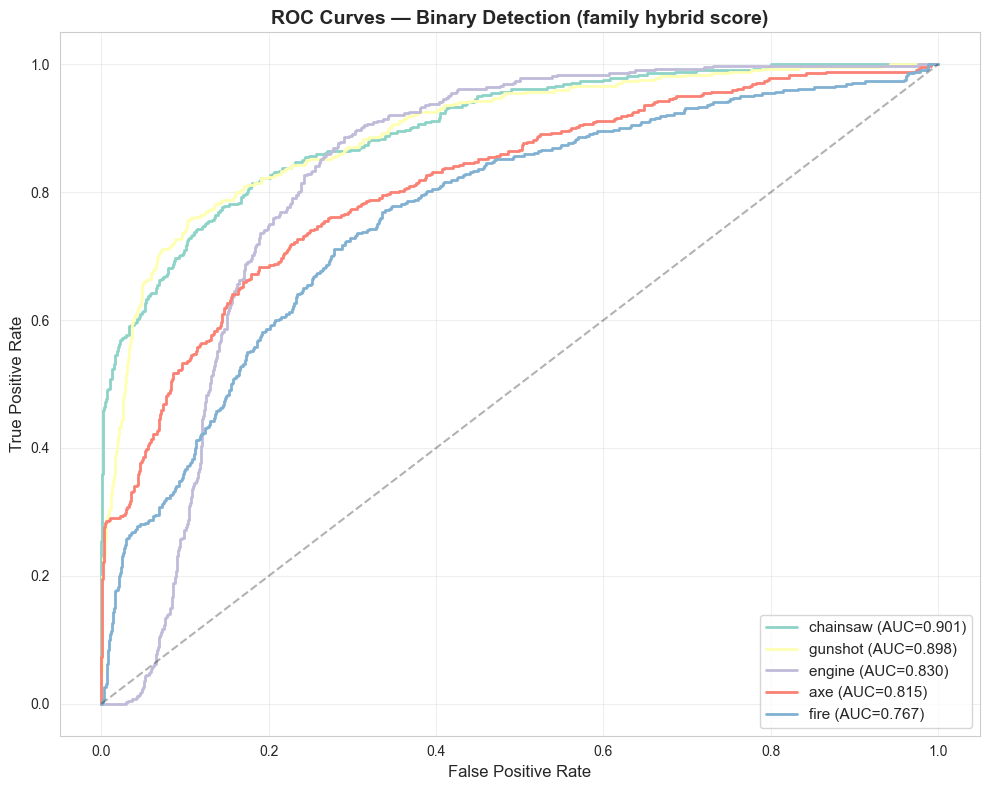

Binary Detection Summary:
  Target   AUC  Threshold  Precision  Recall    F1
chainsaw 0.901      0.003      0.489   0.814 0.611
 gunshot 0.898      0.042      0.608   0.757 0.674
  engine 0.830      0.196      0.393   0.886 0.544
     axe 0.815      0.011      0.435   0.683 0.531
    fire 0.767      0.019      0.352   0.712 0.471

AUC by SNR range:
  SNR >= 5: chainsaw=0.945  gunshot=0.958  engine=0.817  axe=0.874  fire=0.794
  SNR >= 0: chainsaw=0.941  gunshot=0.948  engine=0.842  axe=0.878  fire=0.802
  All SNR: chainsaw=0.901  gunshot=0.898  engine=0.830  axe=0.815  fire=0.767


In [6]:
results_df = pd.read_csv(RESULTS_DIR / 'results_v7.csv')

fig, ax = plt.subplots(figsize=(10, 8))
detection_summary = []
optimal_thresholds = {}

for target in ALL_TARGETS:
    y_true = (results_df['target_class'] == target).astype(int).values
    y_score = results_df[f'hybrid_{target}'].values

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    optimal_thresholds[target] = best_threshold

    y_pred = (y_score >= best_threshold).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    detection_summary.append({
        'Target': target, 'AUC': roc_auc, 'Threshold': best_threshold,
        'Precision': precision, 'Recall': recall, 'F1': f1,
    })
    ax.plot(fpr, tpr, linewidth=2, label=f'{target} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Binary Detection (family hybrid score)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves_v7.png', dpi=150, bbox_inches='tight')
plt.show()

det_df = pd.DataFrame(detection_summary)
print('Binary Detection Summary:')
print(det_df.to_string(index=False, float_format='%.3f'))

print('\nAUC by SNR range:')
for snr_min, label in [(5, 'SNR >= 5'), (0, 'SNR >= 0'), (-10, 'All SNR')]:
    sub = results_df[results_df['snr_db'] >= snr_min]
    aucs = []
    for target in ALL_TARGETS:
        y_true = (sub['target_class'] == target).astype(int).values
        y_score = sub[f'hybrid_{target}'].values
        if len(np.unique(y_true)) < 2: continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        aucs.append(f'{target}={auc(fpr, tpr):.3f}')
    print(f'  {label}: {"  ".join(aucs)}')

## Секция 6 — Сводная таблица метрик

In [7]:
print('=' * 70)
print('СРАВНЕНИЕ МЕТРИК: primary top-1 -> extended top-5 -> binary detection')
print('=' * 70)

print(f'{"Target":<12} {"Primary":<10} {"Extended":<10} {"Family":<10} {"Binary":<10} {"AUC":<8}')
print('-' * 60)

for target in ALL_TARGETS:
    sub = results_df[results_df['target_class'] == target]
    p1 = sub['primary_in_top1'].mean()
    e5 = sub['extended_in_top5'].mean()
    f5 = sub['family_in_top5'].mean()
    threshold = optimal_thresholds[target]
    y_score = sub[f'hybrid_{target}'].values
    binary_rate = (y_score >= threshold).mean()
    det_row = [d for d in detection_summary if d['Target'] == target][0]
    print(f'{target:<12} {p1:<10.1%} {e5:<10.1%} {f5:<10.1%} {binary_rate:<10.1%} {det_row["AUC"]:<8.3f}')

print('\nПрогресс: primary top-1 (~10%) -> extended top-5 (~45%) -> family top-5 -> binary detection (AUC)')

СРАВНЕНИЕ МЕТРИК: primary top-1 -> extended top-5 -> binary detection
Target       Primary    Extended   Family     Binary     AUC     
------------------------------------------------------------
chainsaw     20.2%      42.4%      40.7%      81.4%      0.901   
gunshot      2.6%       50.5%      62.6%      75.7%      0.898   
engine       18.1%      62.1%      93.1%      88.6%      0.830   
axe          8.6%       25.2%      26.0%      68.3%      0.815   
fire         9.8%       32.1%      32.6%      71.2%      0.767   

Прогресс: primary top-1 (~10%) -> extended top-5 (~45%) -> family top-5 -> binary detection (AUC)


## Секция 7 — Визуализация

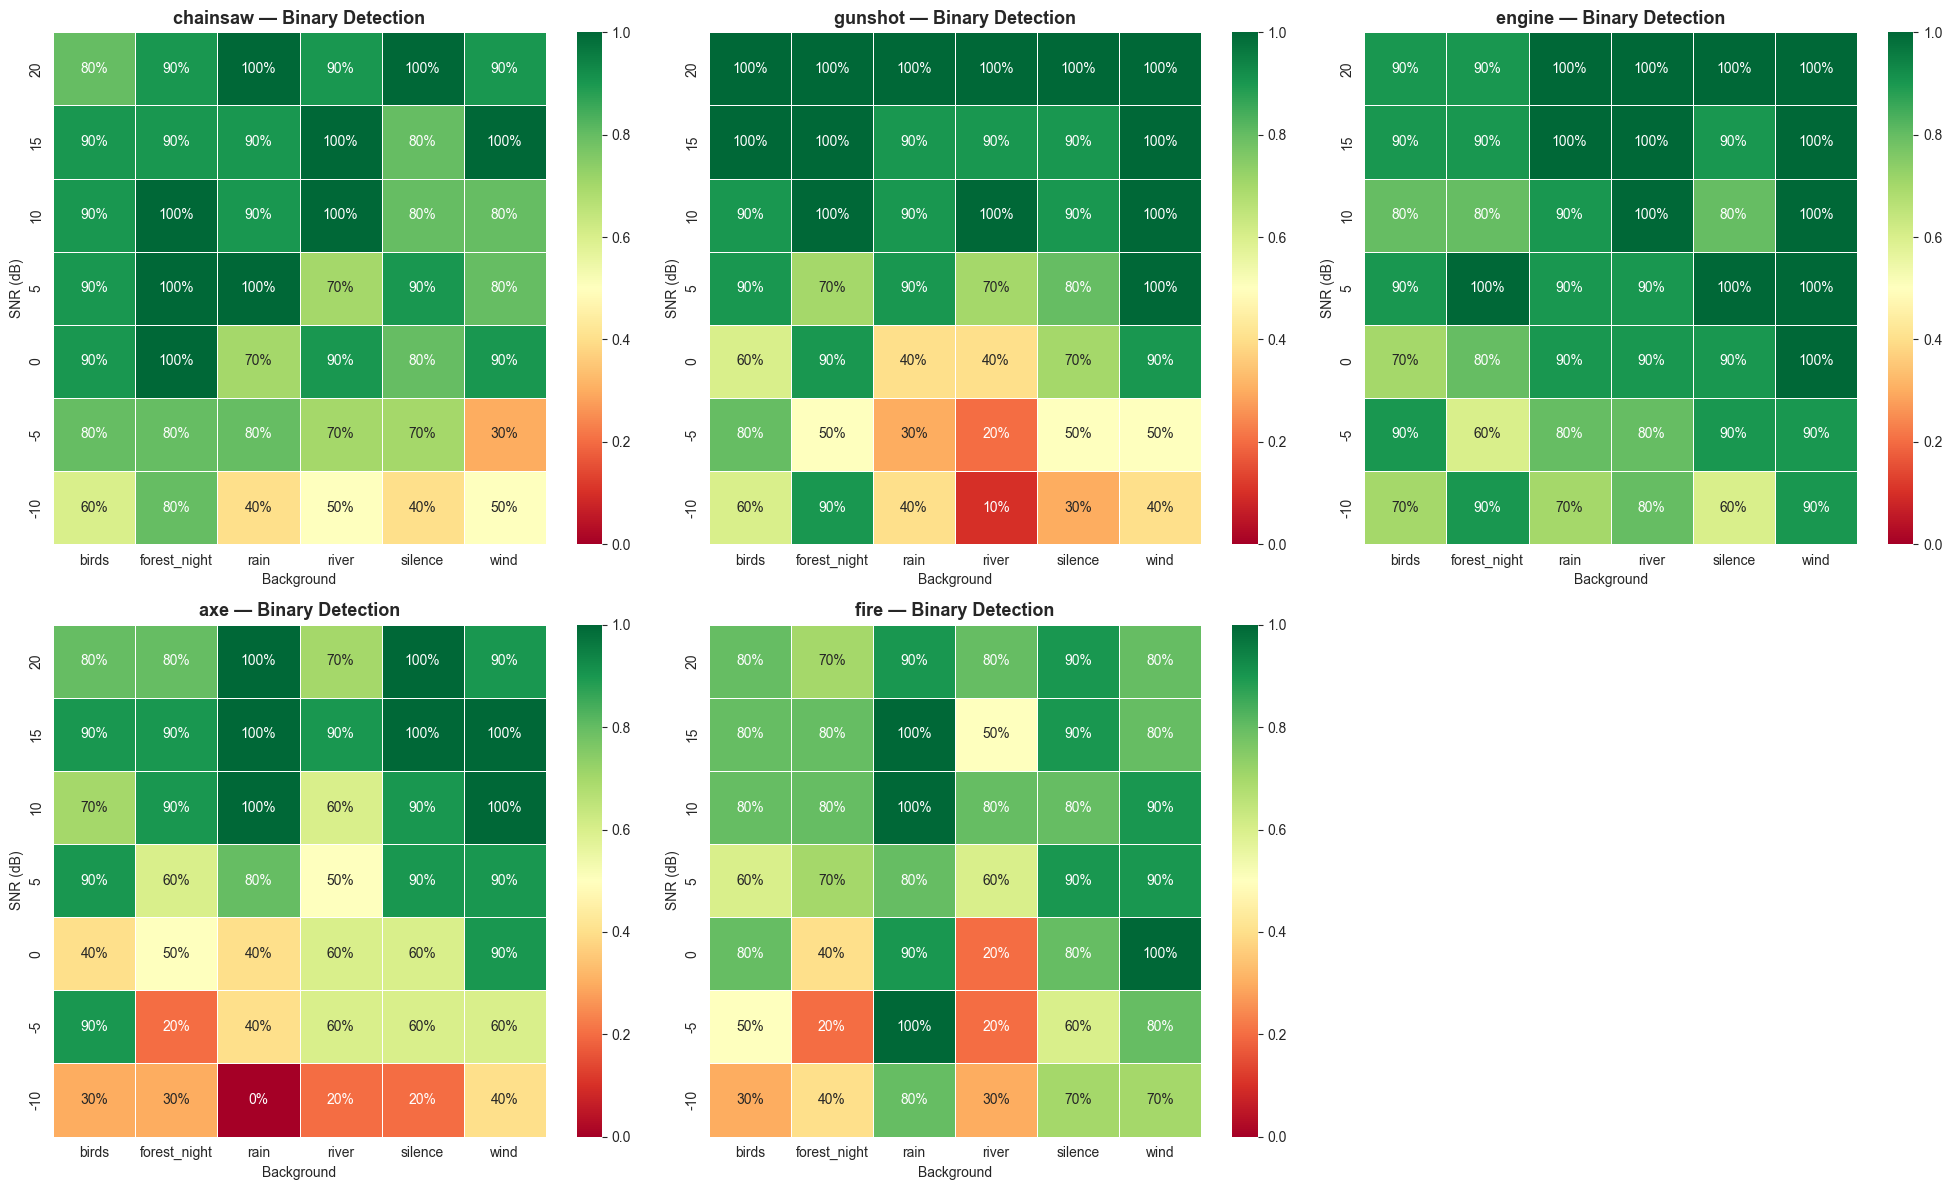

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, target in zip(axes.flat, ALL_TARGETS):
    threshold = optimal_thresholds[target]
    subset = results_df[results_df['target_class'] == target].copy()
    subset['detected'] = subset[f'hybrid_{target}'] >= threshold
    pivot = subset.pivot_table(values='detected', index='snr_db', columns='background_class', aggfunc='mean')
    pivot = pivot.sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.0%', cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.5)
    ax.set_title(f'{target} — Binary Detection', fontsize=13, fontweight='bold')
    ax.set_xlabel('Background')
    ax.set_ylabel('SNR (dB)')
axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'heatmap_binary_detection_v7.png', dpi=150, bbox_inches='tight')
plt.show()

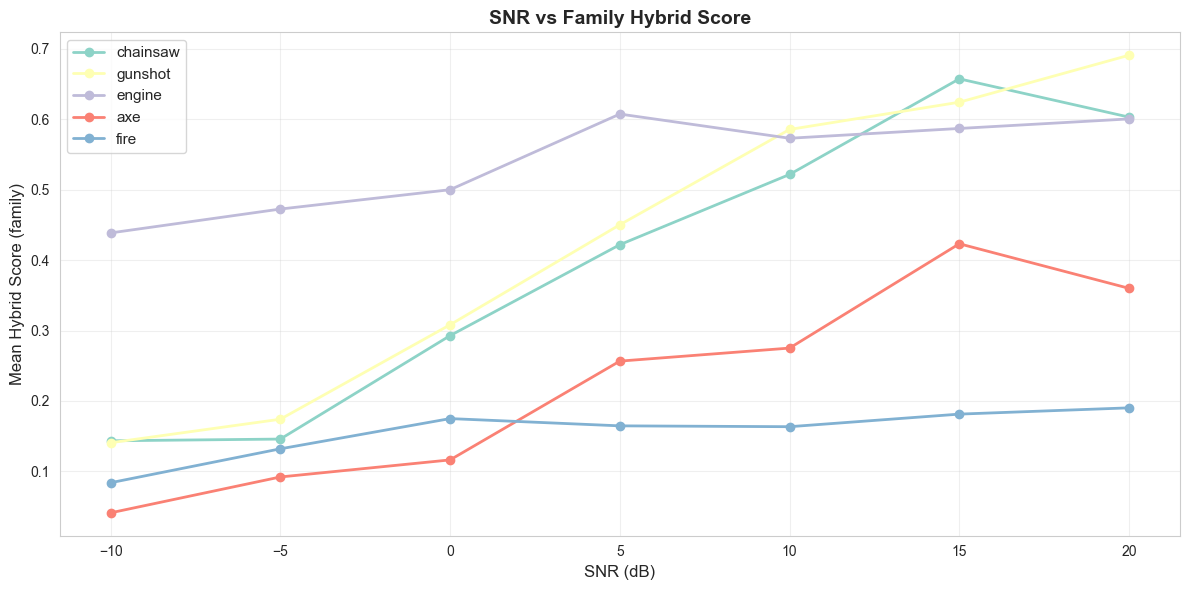

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
for target in ALL_TARGETS:
    subset = results_df[results_df['target_class'] == target]
    mean_by_snr = subset.groupby('snr_db')[f'hybrid_{target}'].mean()
    ax.plot(mean_by_snr.index, mean_by_snr.values, marker='o', linewidth=2, label=target)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Mean Hybrid Score (family)', fontsize=12)
ax.set_title('SNR vs Family Hybrid Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(sorted(results_df['snr_db'].unique()))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'snr_vs_hybrid_score.png', dpi=150, bbox_inches='tight')
plt.show()

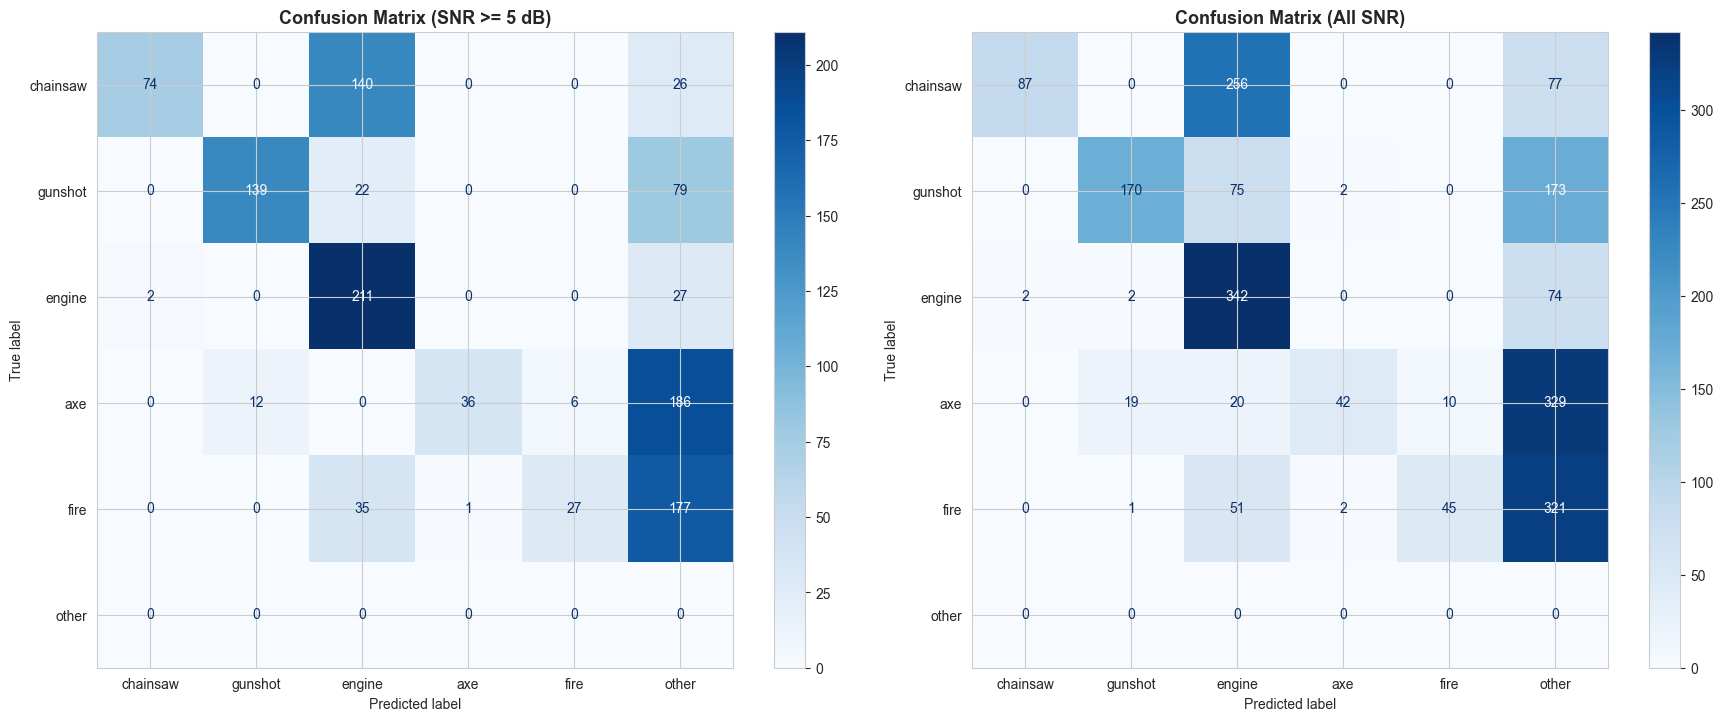

In [10]:
def map_to_target_family(top1_class):
    for target, info in TARGET_CLASSES.items():
        if top1_class in info['family']:
            return target
    return 'other'

results_df['predicted_target'] = results_df['top1_class'].apply(map_to_target_family)
labels = ALL_TARGETS + ['other']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
high_snr = results_df[results_df['snr_db'] >= 5]
cm_high = confusion_matrix(high_snr['target_class'], high_snr['predicted_target'], labels=labels)
ConfusionMatrixDisplay(cm_high, display_labels=labels).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (SNR >= 5 dB)', fontweight='bold', fontsize=13)
cm_all = confusion_matrix(results_df['target_class'], results_df['predicted_target'], labels=labels)
ConfusionMatrixDisplay(cm_all, display_labels=labels).plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Confusion Matrix (All SNR)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_family.png', dpi=150, bbox_inches='tight')
plt.show()

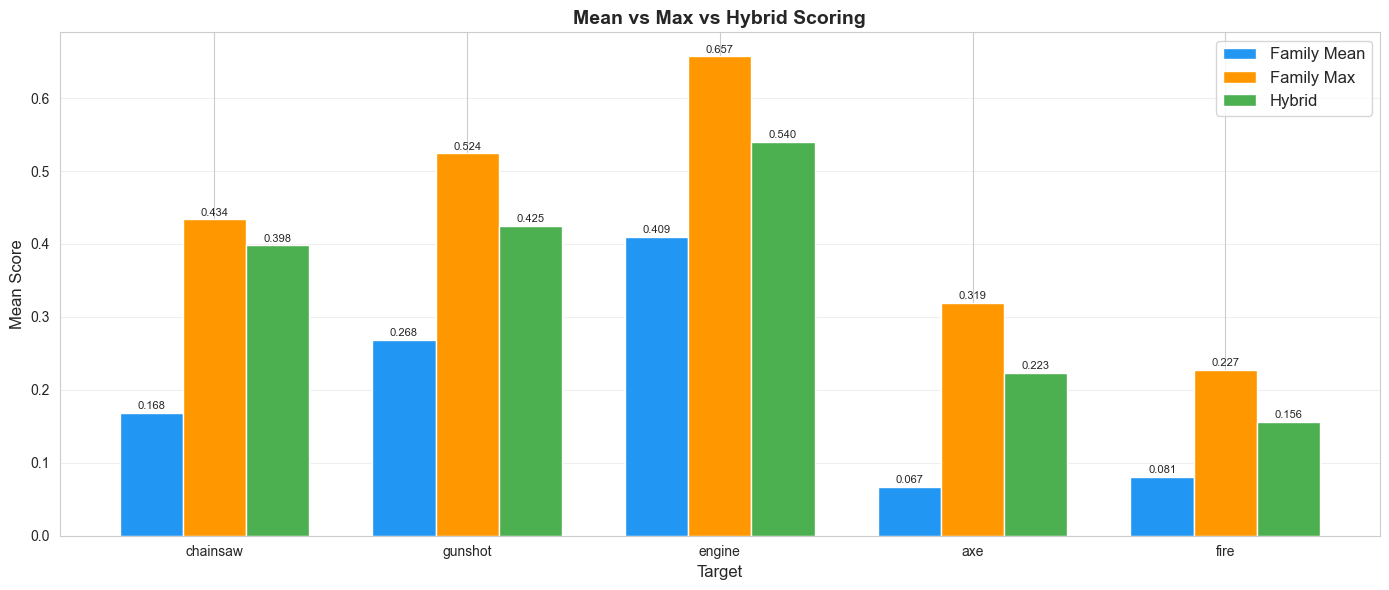

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ALL_TARGETS))
width = 0.25
mean_vals, max_vals, hybrid_vals = [], [], []
for target in ALL_TARGETS:
    sub = results_df[results_df['target_class'] == target]
    mean_vals.append(sub[f'family_mean_{target}'].mean())
    max_vals.append(sub[f'family_max_{target}'].mean())
    hybrid_vals.append(sub[f'hybrid_{target}'].mean())
bars1 = ax.bar(x - width, mean_vals, width, label='Family Mean', color='#2196F3')
bars2 = ax.bar(x, max_vals, width, label='Family Max', color='#FF9800')
bars3 = ax.bar(x + width, hybrid_vals, width, label='Hybrid', color='#4CAF50')
ax.set_xlabel('Target', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_title('Mean vs Max vs Hybrid Scoring', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ALL_TARGETS)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mean_vs_max_vs_hybrid.png', dpi=150, bbox_inches='tight')
plt.show()

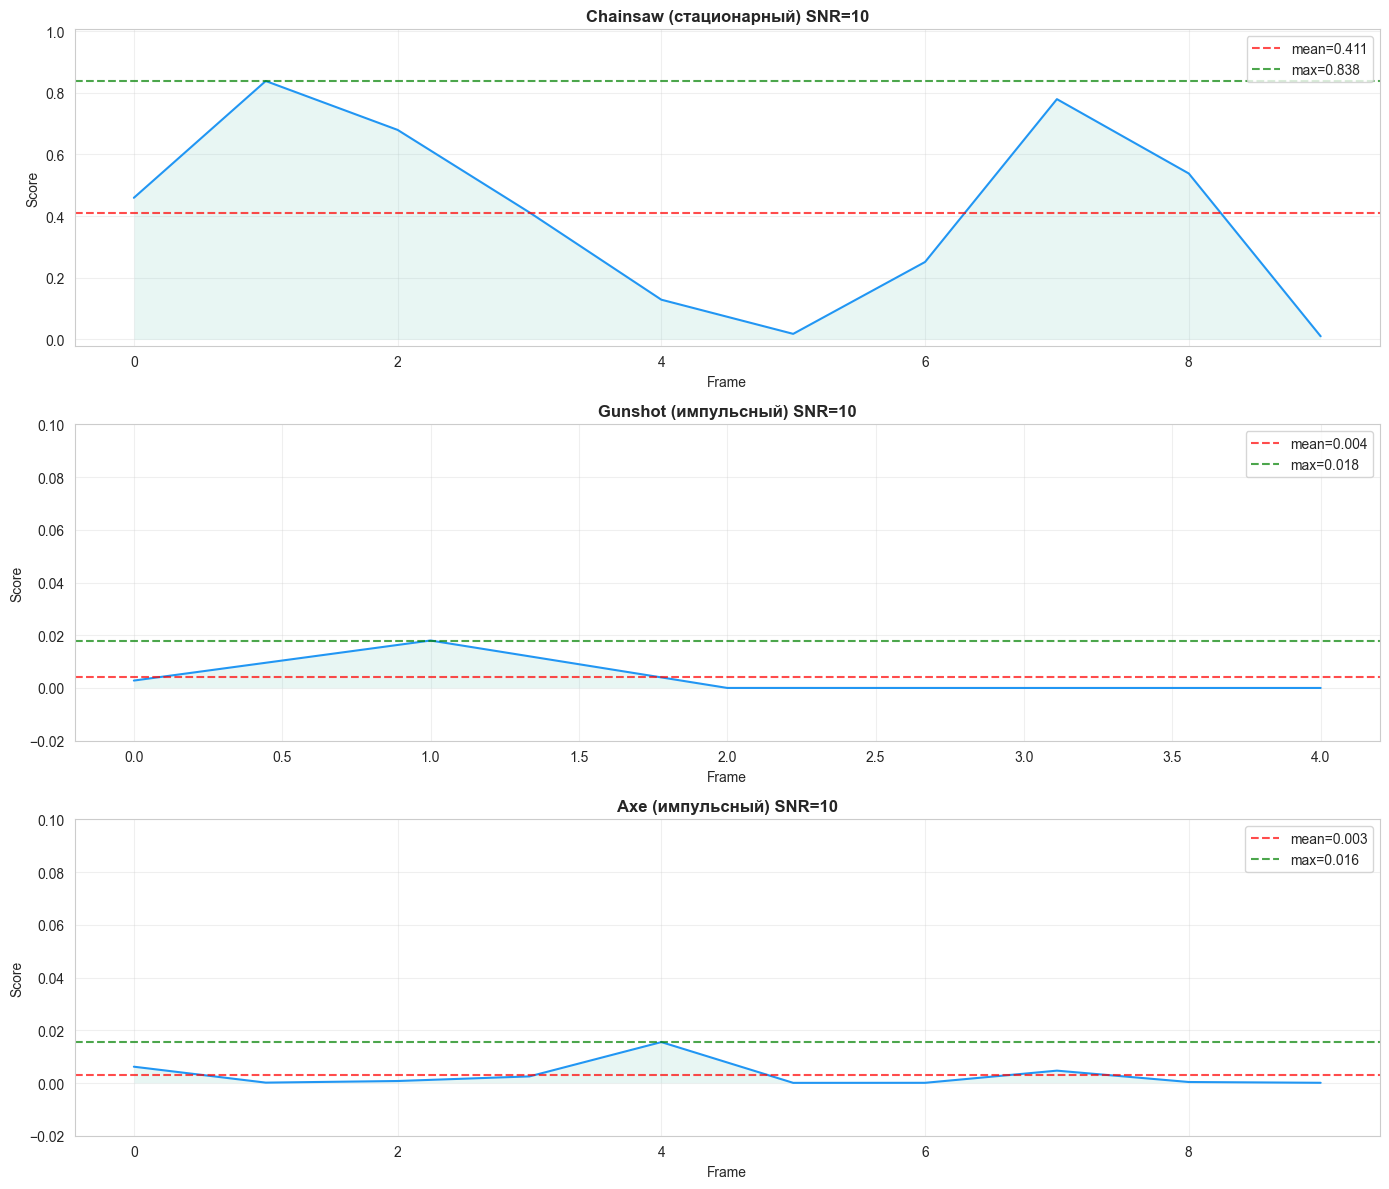

In [12]:
manifest = pd.read_csv(MIXED_DIR / 'manifest.csv')
examples = [
    ('chainsaw', 10, 'Chainsaw (стационарный) SNR=10'),
    ('gunshot', 10, 'Gunshot (импульсный) SNR=10'),
    ('axe', 10, 'Axe (импульсный) SNR=10'),
]
fig, axes = plt.subplots(len(examples), 1, figsize=(14, 4 * len(examples)))
for ax, (target, snr, title) in zip(axes, examples):
    match = manifest[(manifest['target_class'] == target) & (manifest['snr_db'] == snr)].iloc[0]
    filepath = MIXED_DIR / match['filename']
    audio, _ = librosa.load(str(filepath), sr=TARGET_SR)
    waveform = tf.cast(audio, tf.float32)
    scores, embeddings, spectrogram = model(waveform)
    scores_np = scores.numpy()
    primary_idx = TARGET_INDICES[target]['primary']
    target_scores = scores_np[:, primary_idx[0]] if primary_idx else np.zeros(len(scores_np))
    frames = np.arange(len(target_scores))
    ax.plot(frames, target_scores, linewidth=1.5, color='#2196F3')
    ax.axhline(y=target_scores.mean(), color='red', linestyle='--', alpha=0.7, label=f'mean={target_scores.mean():.3f}')
    ax.axhline(y=target_scores.max(), color='green', linestyle='--', alpha=0.7, label=f'max={target_scores.max():.3f}')
    ax.fill_between(frames, target_scores, alpha=0.2)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.02, max(target_scores.max() * 1.2, 0.1))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_frame_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---

# Часть B: Fine-tuning v4

**7 исправлений vs v3 (accuracy 79.4%, val-test gap 15%):**

**Phase 1 — Критические (accuracy 79%→~86%):**
1. **Fix 0 (P0):** SNR range расширен (0,20)→(-5,20) + hard negatives (-10,0). Root cause: 302/433 ошибок (69.7%) = ложное "background" при low SNR
2. **Fix 1 (P1):** Crest Factor scoring удалён — CF на softmax scores ∈[0,1] не может дать CF>4 по определению
3. **Fix 1a (P4a):** Dropout 0.3→0.4 + L2(1e-4) — train-val gap 5%, val-test gap 15%

**Phase 2 — Улучшения (accuracy 86%→~90%):**
4. **Fix 2 (P2):** Pitch shift ±2 полутона + time stretch 0.8-1.2x для fire/axe
5. **Fix 3 (P4):** Label smoothing 0.1 + embedding mixup α=0.4 для axe↔fire confusion

**Phase 3 — Опциональные:**
6. **Fix 6 (H5):** PCEN parallel branch (+3-7% при SNR<10)
7. **Fix 7 (H6):** NDSI двухступенчатая детекция (-30% CPU на edge)

## Секция 8 — Подготовка данных: augmented embeddings (v5)

### v3 → v4: Расширение SNR-диапазона augmentation (Fix 0, P0)

**Проблема v3:** Augmentation использовала SNR range (0, 20) дБ, но тестовые миксы
включают SNR от -10 до +20 дБ. При SNR < 0 модель никогда не видела "слабый target
+ громкий шум" → предсказывала background. Результат: 302 из 433 ошибок (69.7%) —
это ложное предсказание background (аудит v3, секция 2.7).

**Изменение v4:**
- SNR_RANGE: (0, 20) → (-5, 20) — покрываем реалистичный диапазон
- Добавлены hard negatives: N_HARD=3 при SNR (-10, 0) — учат модель отличать
  "очень тихий target" от "чистый фон"
- N_AUG: 5 → 8 (больше разнообразия на расширенном диапазоне)

### v3 → v4: Pitch/speed augmentation для fire и axe (Fix 2, P2)

**Проблема v3:** Fire = 40 clean samples (минимум), ESC-50 "crackling_fire" ≠ лесной пожар.
Axe = 75 samples, FSC22 — не все качественные. Спектральное разнообразие недостаточно.

**Изменение v4:**
- Pitch shift: ±1, ±2 полутона (4 варианта) — librosa.effects.pitch_shift
- Time stretch: 0.8x, 0.9x, 1.1x, 1.2x (4 варианта) — librosa.effects.time_stretch
- Применяется ТОЛЬКО для fire и axe (слабые классы), по 3 SNR-микса на вариант
- Fire: 240 → ~1200 embeddings (5x), Axe: 450 → ~2250 (5x)

**Ожидаемый эффект (Phase 1+2):** overall accuracy 79.4% → ~90%.
**Источник:** ai-engineer анализ confusion matrix v3 + research-analyst.

In [ ]:
# === Configuration v7 ===
# v6 -> v7: PCEN/temporal disabled for prod compatibility (faun uses 2048 only)
N_AUG = 8
SNR_RANGE = (-5, 20)
N_HARD = 3
SNR_HARD_RANGE = (-10, 0)

EMBED_DIM = 1024
USE_CONCAT_POOL = True  # True: mean||max = 2048-dim
YAMNET_DIM = EMBED_DIM * 2 if USE_CONCAT_POOL else EMBED_DIM

# v7: PCEN disabled for prod compatibility (faun uses 2048 only)
USE_PCEN = False
PCEN_DIM = 128  # 64 mean + 64 max

# v7: Temporal disabled for prod compatibility
USE_TEMPORAL = False
TEMPORAL_DIM = 5  # top-5 variance features from YAMNet raw scores

# v7: Total feature dim = 2048 (YAMNet only)
FEATURE_DIM = YAMNET_DIM  # 2048
if USE_PCEN:
    FEATURE_DIM += PCEN_DIM  # + 128 = 2176
if USE_TEMPORAL:
    FEATURE_DIM += TEMPORAL_DIM  # + 5 = 2181

# v5 1.4: Augmentation balance — cap per class
MAX_AUG_PER_CLASS = 1200  # v4: axe=2700, chainsaw=880 → v5: capped at 1200

ALL_LABELS = ALL_TARGETS + ['background']
label_to_idx = {l: i for i, l in enumerate(ALL_LABELS)}
idx_to_label = {i: l for l, i in label_to_idx.items()}

LABEL_SMOOTHING = 0.1

rng = np.random.RandomState(42)

print(f'Classes: {ALL_LABELS}')
print(f'Feature dim: {FEATURE_DIM} (YAMNet={YAMNET_DIM} + PCEN={PCEN_DIM if USE_PCEN else 0} + Temporal={TEMPORAL_DIM if USE_TEMPORAL else 0})')
print(f'Augmentations per sample: {N_AUG}, SNR range: {SNR_RANGE}')
print(f'Hard negatives: {N_HARD} per sample, SNR range: {SNR_HARD_RANGE}')
print(f'Max augmented per class: {MAX_AUG_PER_CLASS}')
print(f'Label smoothing: {LABEL_SMOOTHING}')


def mix_with_snr(signal, noise, snr_db):
    """Mix signal with noise at given SNR (copy from NB01)."""
    if len(noise) < len(signal):
        noise = np.tile(noise, int(np.ceil(len(signal) / len(noise))))
    noise = noise[:len(signal)]
    rms_signal = np.sqrt(np.mean(signal ** 2))
    rms_noise = np.sqrt(np.mean(noise ** 2))
    if rms_noise == 0 or rms_signal == 0:
        return signal.copy()
    target_rms_noise = rms_signal / (10 ** (snr_db / 20))
    noise_scaled = noise * (target_rms_noise / rms_noise)
    mixed = signal + noise_scaled
    peak = np.max(np.abs(mixed))
    if peak > 1.0:
        mixed = mixed / peak
    return mixed


def extract_embedding(audio, use_concat=True):
    """Extract pooled YAMNet embedding from audio.
    Returns: np.array of shape (2048,) if concat, else (1024,)
    """
    waveform = tf.cast(audio, tf.float32)
    _, emb, _ = model(waveform)
    emb_np = emb.numpy()  # (n_frames, 1024)
    mean_emb = emb_np.mean(axis=0)
    if use_concat:
        max_emb = emb_np.max(axis=0)
        return np.concatenate([mean_emb, max_emb])
    return mean_emb


def extract_temporal_variance(audio):
    """v5 1.2: Extract temporal variance features from YAMNet raw scores.

    Axe: высокая variance (удар-пауза-удар)
    Fire: низкая variance (непрерывный треск)
    Returns: top-5 variance features across YAMNet's 521 classes.
    """
    waveform = tf.cast(audio, tf.float32)
    scores, _, _ = model(waveform)
    scores_np = scores.numpy()  # (n_frames, 521)
    if scores_np.shape[0] < 2:
        return np.zeros(TEMPORAL_DIM)
    variance = np.var(scores_np, axis=0)  # (521,)
    # Top-5 most variable classes
    top_indices = np.argsort(variance)[-TEMPORAL_DIM:]
    return variance[top_indices]


def extract_embedding_v6(audio, sr=16000):
    """v5: Combined feature extraction — YAMNet + PCEN + temporal variance.

    Returns: np.array of shape (FEATURE_DIM,)
    """
    yamnet_emb = extract_embedding(audio, USE_CONCAT_POOL)  # 2048
    features = [yamnet_emb]

    if USE_PCEN:
        pcen_emb = pcen_features(audio, sr)  # 128
        features.append(pcen_emb)

    if USE_TEMPORAL:
        temporal = extract_temporal_variance(audio)  # 5
        features.append(temporal)

    return np.concatenate(features)


def augment_audio_variants(audio, sr=16000):
    """v4 Fix 2: Pitch shift + time stretch for weak classes."""
    augmented = []
    for n_steps in [-2, -1, 1, 2]:
        shifted = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)
        augmented.append(shifted)
    for rate in [0.8, 0.9, 1.1, 1.2]:
        stretched = librosa.effects.time_stretch(audio, rate=rate)
        if len(stretched) > len(audio):
            stretched = stretched[:len(audio)]
        else:
            stretched = np.pad(stretched, (0, max(0, len(audio) - len(stretched))))
        augmented.append(stretched)
    return augmented

In [14]:
# === v6: Source file split — data leakage fix ===
# Split source WAV files into train/val/test BEFORE embedding extraction.
# Background files are NOT split (shared across all sets — no meaningful leakage).

def split_source_files(targets_dir, train_ratio=0.7, val_ratio=0.1, seed=42):
    """Split source WAV files into train/val/test to eliminate data leakage."""
    rng_split = np.random.RandomState(seed)
    splits = {}

    for target_name in ALL_TARGETS:
        target_dir = targets_dir / target_name
        if not target_dir.exists():
            print(f'  WARNING: {target_dir} not found')
            continue
        files = sorted([f.name for f in target_dir.glob('*.wav')])
        n = len(files)
        indices = rng_split.permutation(n)

        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)

        train_files = set(files[indices[i]] for i in range(n_train))
        val_files = set(files[indices[i]] for i in range(n_train, n_train + n_val))
        test_files = set(files[indices[i]] for i in range(n_train + n_val, n))

        # Static validation: sets must be disjoint
        assert train_files & val_files == set(), f'{target_name}: train/val overlap!'
        assert train_files & test_files == set(), f'{target_name}: train/test overlap!'
        assert val_files & test_files == set(), f'{target_name}: val/test overlap!'
        assert len(train_files) + len(val_files) + len(test_files) == n

        splits[target_name] = {
            'train': train_files,
            'val': val_files,
            'test': test_files,
        }
        print(f'  {target_name}: {len(train_files)} train / {len(val_files)} val / {len(test_files)} test (total {n})')

    return splits

print('v6 Source file split (70/10/20):')
source_splits = split_source_files(TARGETS_DIR)

# Cross-check: aggregate counts
total_train = sum(len(s['train']) for s in source_splits.values())
total_val = sum(len(s['val']) for s in source_splits.values())
total_test = sum(len(s['test']) for s in source_splits.values())
print(f'\nTotal: {total_train} train / {total_val} val / {total_test} test = {total_train + total_val + total_test}')
print('Static leakage check: PASSED (all sets disjoint)')

v6 Source file split (70/10/20):
  chainsaw: 28 train / 4 val / 8 test (total 40)
  gunshot: 35 train / 5 val / 10 test (total 50)
  engine: 62 train / 9 val / 19 test (total 90)
  axe: 52 train / 7 val / 16 test (total 75)
  fire: 28 train / 4 val / 8 test (total 40)

Total: 205 train / 29 val / 61 test = 295
Static leakage check: PASSED (all sets disjoint)


## Секция 8b — Загрузка фонов и извлечение split-aware embeddings (v6)

**v6 core: Data leakage fix:**
1. Source WAV файлы разбиты на train/val/test ДО извлечения embeddings
2. Clean target embeddings → train/val по split (test пропускается)
3. Augmented embeddings → train из train-файлов, val из val-файлов
4. Background embeddings → все в train (bg не создаёт leakage)
5. Test файлы → оцениваются через миксы из manifest (Секция 10)

In [15]:
# 1. Load all background audio into memory
bg_types = ['rain', 'wind', 'birds', 'forest_night', 'river', 'silence']
bg_audio_pool = {}
for bg_name in bg_types:
    bg_dir = BG_DIR / bg_name
    if not bg_dir.exists():
        continue
    wavs = []
    for wav_file in sorted(bg_dir.glob('*.wav'))[:50]:
        audio, _ = librosa.load(str(wav_file), sr=TARGET_SR)
        wavs.append(audio)
    bg_audio_pool[bg_name] = wavs
    print(f'Background {bg_name}: {len(wavs)} files loaded')

all_bg_audio = []
for wavs in bg_audio_pool.values():
    all_bg_audio.extend(wavs)
print(f'Total background audio clips: {len(all_bg_audio)}')

# 2. Extract CLEAN target embeddings — split-aware (v6)
clean_target_audio = {}  # {class: {'train': [...], 'val': [...]}}
train_clean_emb, train_clean_labels = [], []
val_clean_emb, val_clean_labels = [], []

for target_name in ALL_TARGETS:
    target_dir = TARGETS_DIR / target_name
    if not target_dir.exists():
        continue
    splits = source_splits[target_name]
    audios_train, audios_val = [], []

    for wav_file in sorted(target_dir.glob('*.wav')):
        audio, _ = librosa.load(str(wav_file), sr=TARGET_SR)
        fname = wav_file.name
        emb = extract_embedding_v6(audio, TARGET_SR)

        if fname in splits['train']:
            train_clean_emb.append(emb)
            train_clean_labels.append(label_to_idx[target_name])
            audios_train.append(audio)
        elif fname in splits['val']:
            val_clean_emb.append(emb)
            val_clean_labels.append(label_to_idx[target_name])
            audios_val.append(audio)
        # test files: skip (evaluated via mixes in Секция 10)

    clean_target_audio[target_name] = {'train': audios_train, 'val': audios_val}
    print(f'{target_name}: {len(audios_train)} train + {len(audios_val)} val clean')

# 3. Extract CLEAN background embeddings — all in train (no bg leakage)
bg_count = 0
for bg_name in bg_types:
    bg_dir = BG_DIR / bg_name
    if not bg_dir.exists():
        continue
    count = 0
    for wav_file in sorted(bg_dir.glob('*.wav'))[:50]:
        audio, _ = librosa.load(str(wav_file), sr=TARGET_SR)
        emb = extract_embedding_v6(audio, TARGET_SR)
        train_clean_emb.append(emb)
        train_clean_labels.append(label_to_idx['background'])
        count += 1
    bg_count += count
    print(f'background/{bg_name}: {count} (-> train)')

# Background augmentation — intensity variations + combos (all in train)
bg_aug_count = 0
for bg_name in bg_types:
    wavs = bg_audio_pool.get(bg_name, [])
    for audio in wavs[:20]:
        for scale in [0.5, 0.7, 1.3]:
            scaled = audio * scale
            emb = extract_embedding_v6(scaled, TARGET_SR)
            train_clean_emb.append(emb)
            train_clean_labels.append(label_to_idx['background'])
            bg_aug_count += 1
    if len(wavs) >= 2:
        for _ in range(10):
            idx1, idx2 = rng.choice(len(wavs), 2, replace=False)
            combo = mix_with_snr(wavs[idx1], wavs[idx2], rng.uniform(-3, 3))
            emb = extract_embedding_v6(combo, TARGET_SR)
            train_clean_emb.append(emb)
            train_clean_labels.append(label_to_idx['background'])
            bg_aug_count += 1

print(f'background total: {bg_count} clean + {bg_aug_count} augmented (-> train)')

# 4. Generate AUGMENTED target embeddings — split-aware (v6)
print(f'\nGenerating augmented embeddings (v6: split-aware)...')
print(f'  Standard: N_AUG={N_AUG}, SNR={SNR_RANGE}')
print(f'  Hard negatives: N_HARD={N_HARD}, SNR={SNR_HARD_RANGE}')
print(f'  Max per class (train): {MAX_AUG_PER_CLASS}')

train_aug_emb, train_aug_labels = [], []
val_aug_emb, val_aug_labels = [], []

for target_name in ALL_TARGETS:
    # --- Train augmented (from train files, capped) ---
    audios = clean_target_audio[target_name]['train']
    count_total = 0
    for audio in audios:
        if count_total >= MAX_AUG_PER_CLASS:
            break
        for _ in range(N_AUG):
            if count_total >= MAX_AUG_PER_CLASS:
                break
            bg_clip = all_bg_audio[rng.randint(0, len(all_bg_audio))]
            snr_db = rng.uniform(SNR_RANGE[0], SNR_RANGE[1])
            mixed = mix_with_snr(audio, bg_clip, snr_db)
            emb = extract_embedding_v6(mixed, TARGET_SR)
            train_aug_emb.append(emb)
            train_aug_labels.append(label_to_idx[target_name])
            count_total += 1
        for _ in range(N_HARD):
            if count_total >= MAX_AUG_PER_CLASS:
                break
            bg_clip = all_bg_audio[rng.randint(0, len(all_bg_audio))]
            snr_db = rng.uniform(SNR_HARD_RANGE[0], SNR_HARD_RANGE[1])
            mixed = mix_with_snr(audio, bg_clip, snr_db)
            emb = extract_embedding_v6(mixed, TARGET_SR)
            train_aug_emb.append(emb)
            train_aug_labels.append(label_to_idx[target_name])
            count_total += 1
    print(f'{target_name}: {count_total} train augmented')

    # --- Val augmented (from val files, no cap) ---
    audios_val = clean_target_audio[target_name]['val']
    val_count = 0
    for audio in audios_val:
        for _ in range(N_AUG):
            bg_clip = all_bg_audio[rng.randint(0, len(all_bg_audio))]
            snr_db = rng.uniform(SNR_RANGE[0], SNR_RANGE[1])
            mixed = mix_with_snr(audio, bg_clip, snr_db)
            emb = extract_embedding_v6(mixed, TARGET_SR)
            val_aug_emb.append(emb)
            val_aug_labels.append(label_to_idx[target_name])
            val_count += 1
    print(f'  + {val_count} val augmented')

# 5. Pitch/speed augmentation for weak classes — train only
WEAK_CLASSES = ['fire', 'axe']
print(f'\nPitch/speed augmentation for {WEAK_CLASSES} (train only)...')

for target_name in WEAK_CLASSES:
    audios = clean_target_audio[target_name]['train']
    existing = sum(1 for l in train_aug_labels if l == label_to_idx[target_name])
    remaining = MAX_AUG_PER_CLASS - existing
    count = 0
    for audio in audios:
        if count >= remaining:
            break
        variants = augment_audio_variants(audio, sr=TARGET_SR)
        for variant in variants:
            if count >= remaining:
                break
            bg_clip = all_bg_audio[rng.randint(0, len(all_bg_audio))]
            snr_db = rng.uniform(-5, 15)
            mixed = mix_with_snr(variant, bg_clip, snr_db)
            emb = extract_embedding_v6(mixed, TARGET_SR)
            train_aug_emb.append(emb)
            train_aug_labels.append(label_to_idx[target_name])
            count += 1
    print(f'  {target_name}: +{count} pitch/speed (train total: {existing + count})')

# 6. Summary
print(f'\n{"=" * 50}')
print(f'Train: {len(train_clean_emb)} clean + {len(train_aug_emb)} aug = {len(train_clean_emb) + len(train_aug_emb)}')
print(f'Val:   {len(val_clean_emb)} clean + {len(val_aug_emb)} aug = {len(val_clean_emb) + len(val_aug_emb)}')
print(f'Test:  evaluated on filtered mixes from manifest')

print(f'\nTrain class distribution:')
all_train_labels = train_clean_labels + train_aug_labels
for label_name, idx in label_to_idx.items():
    count = sum(1 for l in all_train_labels if l == idx)
    print(f'  {label_name}: {count}')

Background rain: 40 files loaded
Background wind: 40 files loaded
Background birds: 50 files loaded
Background forest_night: 40 files loaded
Background river: 40 files loaded
Background silence: 50 files loaded
Total background audio clips: 260
chainsaw: 28 train + 4 val clean
gunshot: 35 train + 5 val clean
engine: 62 train + 9 val clean
axe: 52 train + 7 val clean
fire: 28 train + 4 val clean
background/rain: 40 (-> train)
background/wind: 40 (-> train)
background/birds: 50 (-> train)
background/forest_night: 40 (-> train)
background/river: 40 (-> train)
background/silence: 50 (-> train)
background total: 260 clean + 420 augmented (-> train)

Generating augmented embeddings (v6: split-aware)...
  Standard: N_AUG=8, SNR=(-5, 20)
  Hard negatives: N_HARD=3, SNR=(-10, 0)
  Max per class (train): 1200
chainsaw: 308 train augmented
  + 32 val augmented
gunshot: 385 train augmented
  + 40 val augmented
engine: 682 train augmented
  + 72 val augmented
axe: 572 train augmented
  + 56 val aug

## Секция 9 — Архитектура v7 + обучение (leak-free, 2048-dim)

### v6 -> v7:
- **PCEN/temporal disabled** — FEATURE_DIM=2048 для совместимости с faun inference
- Архитектура и гиперпараметры без изменений (Dense 256→128→6)

### v5 -> v6:
- **Убран train_test_split** — train/val формируются из pre-built массивов по source file split
- **Val = clean + augmented** из val-файлов (v5: clean-only val из random split)

v7 leak-free split (2048-dim):
  Train: 3780 (clean 885 + aug 2895)
  Val:   261 (clean 29 + aug 232)

Label smoothing: 0.1

Embedding mixup:
  axe <-> fire: 200 mixup samples

Final training set: 3980 (train 3780 + mixup 200)

Class weights (balanced):
  chainsaw: 1.875
  gunshot: 1.500
  engine: 0.847
  axe: 0.606
  fire: 1.125
  background: 0.926


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,750 (2.14 MB)

 Trainable params: 558,982 (2.13 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3794 - loss: 1.7187 - val_accuracy: 0.7471 - val_loss: 1.0529 - learning_rate: 1.0000e-04
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6010 - loss: 1.3218 - val_accuracy: 0.8123 - val_loss: 0.7370 - learning_rate: 1.0000e-04
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6590 - loss: 1.2135 - val_accuracy: 0.8199 - val_loss: 0.6257 - learning_rate: 1.0000e-04
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6937 - loss: 1.1405 - val_accuracy: 0.8582 - val_loss: 0.5585 - learning_rate: 1.0000e-04
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7153 - loss: 1.1034 - val_accuracy: 0.8736 - val_loss: 0.5192 - learning_rate: 1.0000e-04
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7307 - loss: 1.0724 - val_accuracy: 0.8697 - val_loss: 0.4956 - learning_rate: 1.0000e-04
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

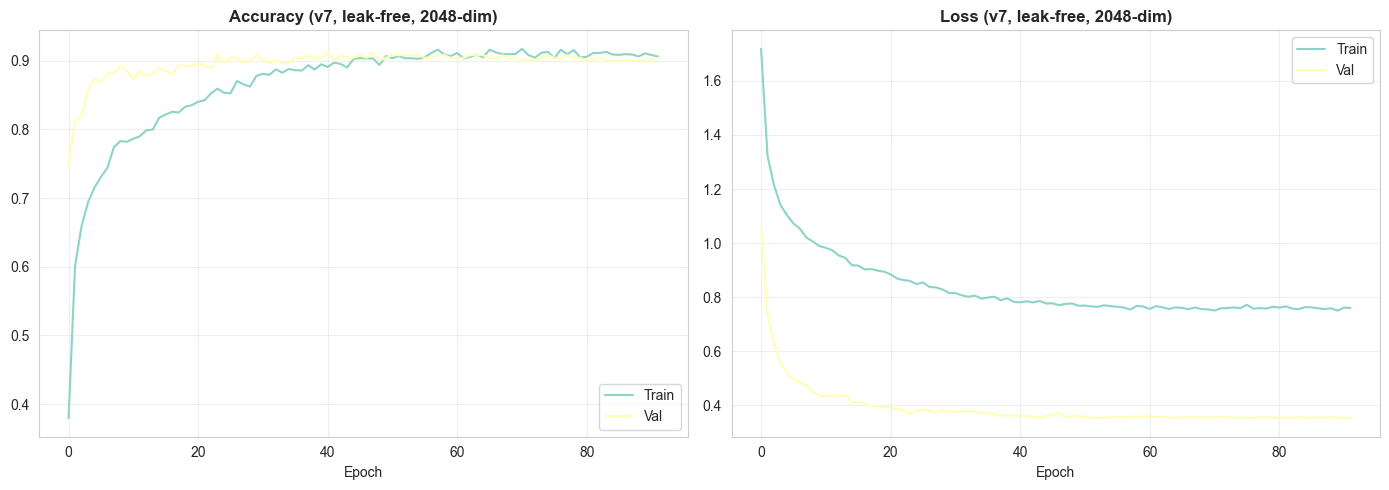


Final val accuracy: 91.2%


In [16]:
# v6: Pre-built train/val arrays from split-aware extraction (no train_test_split)
X_train_clean_arr = np.array(train_clean_emb)
y_train_clean_arr = np.array(train_clean_labels)
X_train_aug_arr = np.array(train_aug_emb)
y_train_aug_arr = np.array(train_aug_labels)

X_val_clean_arr = np.array(val_clean_emb)
y_val_clean_arr = np.array(val_clean_labels)
X_val_aug_arr = np.array(val_aug_emb) if val_aug_emb else np.zeros((0, FEATURE_DIM))
y_val_aug_arr = np.array(val_aug_labels) if val_aug_labels else np.zeros(0, dtype=int)

# Combine clean + augmented for each set
X_train = np.concatenate([X_train_clean_arr, X_train_aug_arr])
y_train = np.concatenate([y_train_clean_arr, y_train_aug_arr])

X_val = np.concatenate([X_val_clean_arr, X_val_aug_arr])
y_val = np.concatenate([y_val_clean_arr, y_val_aug_arr])

print(f'v7 leak-free split (2048-dim):')
print(f'  Train: {len(X_train)} (clean {len(X_train_clean_arr)} + aug {len(X_train_aug_arr)})')
print(f'  Val:   {len(X_val)} (clean {len(X_val_clean_arr)} + aug {len(X_val_aug_arr)})')

# Label smoothing
n_classes = len(ALL_LABELS)
y_train_smooth = np.full((len(y_train), n_classes),
                          LABEL_SMOOTHING / (n_classes - 1))
for i, label in enumerate(y_train):
    y_train_smooth[i, label] = 1.0 - LABEL_SMOOTHING

y_val_onehot = np.zeros((len(y_val), n_classes))
for i, label in enumerate(y_val):
    y_val_onehot[i, label] = 1.0

print(f'\nLabel smoothing: {LABEL_SMOOTHING}')

# Embedding mixup for confusing pairs (axe<->fire)
MIXUP_PAIRS = [(label_to_idx['axe'], label_to_idx['fire'])]
N_MIXUP = 200
MIXUP_ALPHA = 1.0

print(f'\nEmbedding mixup:')
X_mix_all, y_mix_all = [], []
for cls_a, cls_b in MIXUP_PAIRS:
    idx_a = np.where(y_train == cls_a)[0]
    idx_b = np.where(y_train == cls_b)[0]
    for _ in range(N_MIXUP):
        lam = rng.beta(MIXUP_ALPHA, MIXUP_ALPHA)
        x_new = lam * X_train[rng.choice(idx_a)] + (1 - lam) * X_train[rng.choice(idx_b)]
        y_new = np.zeros(n_classes)
        y_new[cls_a] = lam
        y_new[cls_b] = 1 - lam
        X_mix_all.append(x_new)
        y_mix_all.append(y_new)
    print(f'  {idx_to_label[cls_a]} <-> {idx_to_label[cls_b]}: {N_MIXUP} mixup samples')

X_train_final = np.concatenate([X_train, np.array(X_mix_all)])
y_train_final = np.concatenate([y_train_smooth, np.array(y_mix_all)])
print(f'\nFinal training set: {len(X_train_final)} (train {len(X_train)} + mixup {len(X_mix_all)})')

# Sample weights
classes_all = np.unique(y_train)
weights_map = compute_class_weight('balanced', classes=classes_all, y=y_train)
class_weight_map = dict(zip(classes_all.astype(int), weights_map))
print(f'\nClass weights (balanced):')
for idx, w in class_weight_map.items():
    print(f'  {idx_to_label[idx]}: {w:.3f}')

sample_weights = np.array([
    class_weight_map[int(np.argmax(y_train_final[i]))]
    for i in range(len(y_train_final))
])

# Architecture v7: FEATURE_DIM=2048 (prod-compatible)
classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(FEATURE_DIM,)),
    tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(len(ALL_LABELS), activation='softmax'),
])

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

classifier.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1,
    ),
]

history = classifier.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val_onehot),
    epochs=150, batch_size=32,
    sample_weight=sample_weights,
    callbacks=callbacks,
    verbose=1,
)

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy (v7, leak-free, 2048-dim)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss (v7, leak-free, 2048-dim)', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v7.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFinal val accuracy: {max(history.history["val_accuracy"]):.1%}')

## Секция 10 — Оценка на leak-free test set (v7)

### v7:
- **FEATURE_DIM=2048** — prod-compatible (faun inference)

### v6 core:
- **Filtered test set:** только миксы из test-файлов + background-only
- **Runtime leakage assertion:** проверка что train/val/test файлы не пересекаются
- **TODO-16: Confidence gating** — log_only (< 0.4) / verify (0.4-0.7) / alert (> 0.7)
- **TODO-02: FPR test** — false positive rate на background-only семплах (target < 5%)
- **Fire+axe alert merge** (из v5): low confidence → `fire_or_impact`

Total manifest: 2400
Test manifest (leak-free): 702
  Target mixes: 402
  Background-only: 300
Runtime leakage check: PASSED (0 overlapping files)

Overall accuracy (leak-free, 2048-dim): 82.1%
v6 baseline (2181-dim): ~85.8%
Alert accuracy (fire+axe merged): 86.1%

Accuracy by target:
  chainsaw: 87.5% (72 mixes)
  gunshot: 98.8% (80 mixes)
  engine: 76.9% (91 mixes)
  axe: 67.5% (80 mixes)
  fire: 81.0% (79 mixes)

Accuracy by SNR:
  SNR=-10: 50.7%
  SNR=-5: 78.8%
  SNR=+0: 81.0%
  SNR=+5: 89.5%
  SNR=+10: 95.2%
  SNR=+15: 90.7%
  SNR=+20: 93.7%

Accuracy by SNR band:
  SNR >=10: 93.5% (168 mixes)
  SNR 0-10: 85.2% (115 mixes)
  SNR <0: 63.0% (119 mixes)

FPR (background-only): 26.0% (78/300)
Target: FPR < 5%  ->  FAIL
False positive breakdown:
predicted_class
fire        30
engine      22
axe         10
gunshot      9
chainsaw     7

Confidence gating distribution (target mixes):
  alert: 301 (74.9%), accuracy=95.0%
  verify: 86 (21.4%), accuracy=48.8%
  log_only: 15 (3.7%), accuracy

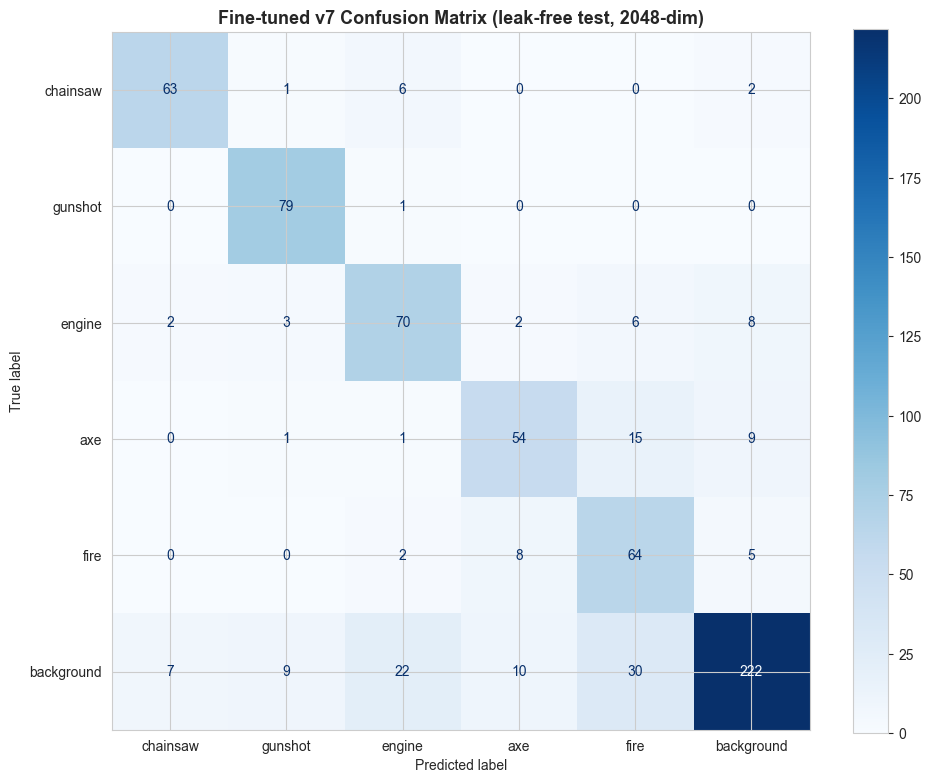

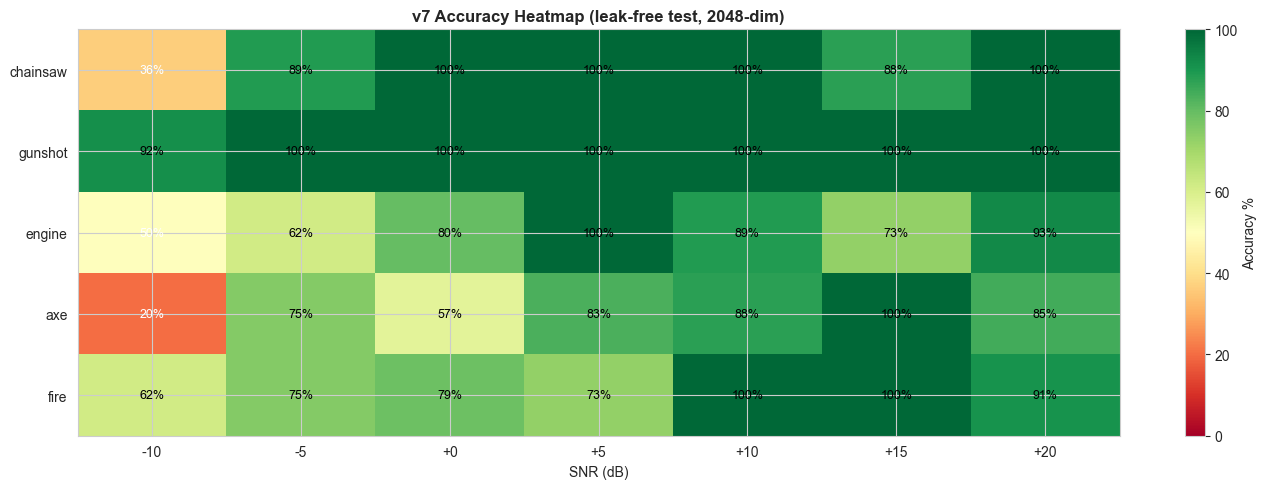

In [17]:
# === v7: Leak-free evaluation (2048-dim) ===
manifest = pd.read_csv(MIXED_DIR / 'manifest.csv')

# Build set of test source files
test_source_files = set()
for target_name, splits in source_splits.items():
    test_source_files.update(splits['test'])

# Filter manifest: keep only mixes from test files + bg-only
test_manifest = manifest[
    (manifest['source_target_file'].isin(test_source_files)) |
    (manifest['target_class'] == 'background')
].copy()

print(f'Total manifest: {len(manifest)}')
print(f'Test manifest (leak-free): {len(test_manifest)}')
print(f'  Target mixes: {len(test_manifest[test_manifest["target_class"] != "background"])}')
print(f'  Background-only: {len(test_manifest[test_manifest["target_class"] == "background"])}')

# Runtime leakage assertion
train_val_files = set()
for target_name, splits in source_splits.items():
    train_val_files.update(splits['train'])
    train_val_files.update(splits['val'])

test_mix_sources = set(
    test_manifest[test_manifest['target_class'] != 'background']['source_target_file']
)
leaked = test_mix_sources & train_val_files
assert len(leaked) == 0, f'LEAKAGE DETECTED: {leaked}'
print('Runtime leakage check: PASSED (0 overlapping files)')

# Confidence gating thresholds (TODO-16)
GATE_LOG_ONLY = 0.4
GATE_VERIFY = 0.7

def confidence_gate(confidence):
    if confidence < GATE_LOG_ONLY:
        return 'log_only'
    elif confidence < GATE_VERIFY:
        return 'verify'
    else:
        return 'alert'

# Run evaluation
ft_results = []

for i, row in test_manifest.iterrows():
    filepath = MIXED_DIR / row['filename']
    audio, _ = librosa.load(str(filepath), sr=TARGET_SR)

    emb = extract_embedding_v6(audio, TARGET_SR).reshape(1, -1)
    probs = classifier.predict(emb, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_label = ALL_LABELS[pred_idx]
    confidence = float(probs[pred_idx])
    gt_idx = label_to_idx[row['target_class']]

    # Fire+axe alert merge (from v5)
    alert_label = pred_label
    fire_idx = label_to_idx['fire']
    axe_idx = label_to_idx['axe']
    if pred_label in ('fire', 'axe') and confidence < 0.7:
        combined_conf = float(probs[fire_idx] + probs[axe_idx])
        alert_label = 'fire_or_impact'
    else:
        combined_conf = confidence

    # Confidence gating (TODO-16)
    gate = confidence_gate(confidence)

    result = {
        'filename': row['filename'],
        'target_class': row['target_class'],
        'background_class': row['background_class'],
        'snr_db': row['snr_db'],
        'predicted_class': pred_label,
        'alert_label': alert_label,
        'confidence': confidence,
        'combined_confidence': combined_conf,
        'confidence_gate': gate,
        'target_score': float(probs[gt_idx]),
        'correct': pred_label == row['target_class'],
    }
    for j, label in enumerate(ALL_LABELS):
        result[f'prob_{label}'] = float(probs[j])
    ft_results.append(result)

ft_df = pd.DataFrame(ft_results)
ft_df.to_csv(RESULTS_DIR / 'results_finetuned_v7.csv', index=False)

# === Results ===
target_df = ft_df[ft_df['target_class'] != 'background']
print(f'\nOverall accuracy (leak-free, 2048-dim): {target_df["correct"].mean():.1%}')
print(f'v6 baseline (2181-dim): ~85.8%')

# Alert accuracy
alert_correct = target_df['correct'].copy()
for i, row in target_df.iterrows():
    if row['alert_label'] == 'fire_or_impact' and row['target_class'] in ('fire', 'axe'):
        alert_correct.loc[i] = True
print(f'Alert accuracy (fire+axe merged): {alert_correct.mean():.1%}')

print('\nAccuracy by target:')
for target in ALL_TARGETS:
    sub = target_df[target_df['target_class'] == target]
    if len(sub) > 0:
        print(f'  {target}: {sub["correct"].mean():.1%} ({len(sub)} mixes)')

print('\nAccuracy by SNR:')
for snr in sorted(target_df['snr_db'].unique()):
    sub = target_df[target_df['snr_db'] == snr]
    print(f'  SNR={snr:+d}: {sub["correct"].mean():.1%}')

print('\nAccuracy by SNR band:')
for snr_band, lo, hi in [('>=10', 10, 100), ('0-10', 0, 9), ('<0', -100, -1)]:
    sub = target_df[(target_df['snr_db'] >= lo) & (target_df['snr_db'] <= hi)]
    if len(sub) > 0:
        print(f'  SNR {snr_band}: {sub["correct"].mean():.1%} ({len(sub)} mixes)')

# === TODO-02: FPR report ===
bg_only_df = ft_df[ft_df['target_class'] == 'background']
if len(bg_only_df) > 0:
    bg_false_positives = bg_only_df[bg_only_df['predicted_class'] != 'background']
    fpr = len(bg_false_positives) / len(bg_only_df)
    print(f'\nFPR (background-only): {fpr:.1%} ({len(bg_false_positives)}/{len(bg_only_df)})')
    print(f'Target: FPR < 5%  ->  {"PASS" if fpr < 0.05 else "FAIL"}')
    if len(bg_false_positives) > 0:
        print('False positive breakdown:')
        print(bg_false_positives['predicted_class'].value_counts().to_string())

# === TODO-16: Confidence gating report ===
print('\nConfidence gating distribution (target mixes):')
for gate in ['alert', 'verify', 'log_only']:
    sub = target_df[target_df['confidence_gate'] == gate]
    if len(sub) > 0:
        acc = sub['correct'].mean()
        print(f'  {gate}: {len(sub)} ({len(sub)/len(target_df)*100:.1f}%), accuracy={acc:.1%}')

# Confusion matrix
cm_labels = ALL_TARGETS + ['background']
cm = confusion_matrix(ft_df['target_class'], ft_df['predicted_class'], labels=cm_labels)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=cm_labels).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Fine-tuned v7 Confusion Matrix (leak-free test, 2048-dim)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_finetuned_v7.png', dpi=150, bbox_inches='tight')
plt.show()

# Accuracy heatmap
snr_levels = sorted(target_df['snr_db'].unique())
heatmap_data = []
for target in ALL_TARGETS:
    row = []
    for snr in snr_levels:
        sub = target_df[(target_df['target_class'] == target) & (target_df['snr_db'] == snr)]
        row.append(sub['correct'].mean() * 100 if len(sub) > 0 else 0)
    heatmap_data.append(row)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(len(snr_levels)))
ax.set_xticklabels([f'{s:+d}' for s in snr_levels])
ax.set_yticks(range(len(ALL_TARGETS)))
ax.set_yticklabels(ALL_TARGETS)
ax.set_xlabel('SNR (dB)')
ax.set_title('v7 Accuracy Heatmap (leak-free test, 2048-dim)', fontweight='bold')
for i in range(len(ALL_TARGETS)):
    for j in range(len(snr_levels)):
        ax.text(j, i, f'{heatmap_data[i][j]:.0f}%', ha='center', va='center',
                color='black' if heatmap_data[i][j] > 50 else 'white', fontsize=9)
plt.colorbar(im, label='Accuracy %')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_heatmap_v7.png', dpi=150, bbox_inches='tight')
plt.show()

## Секция 11 — Сравнение: pretrained vs fine-tuned v3 vs v4

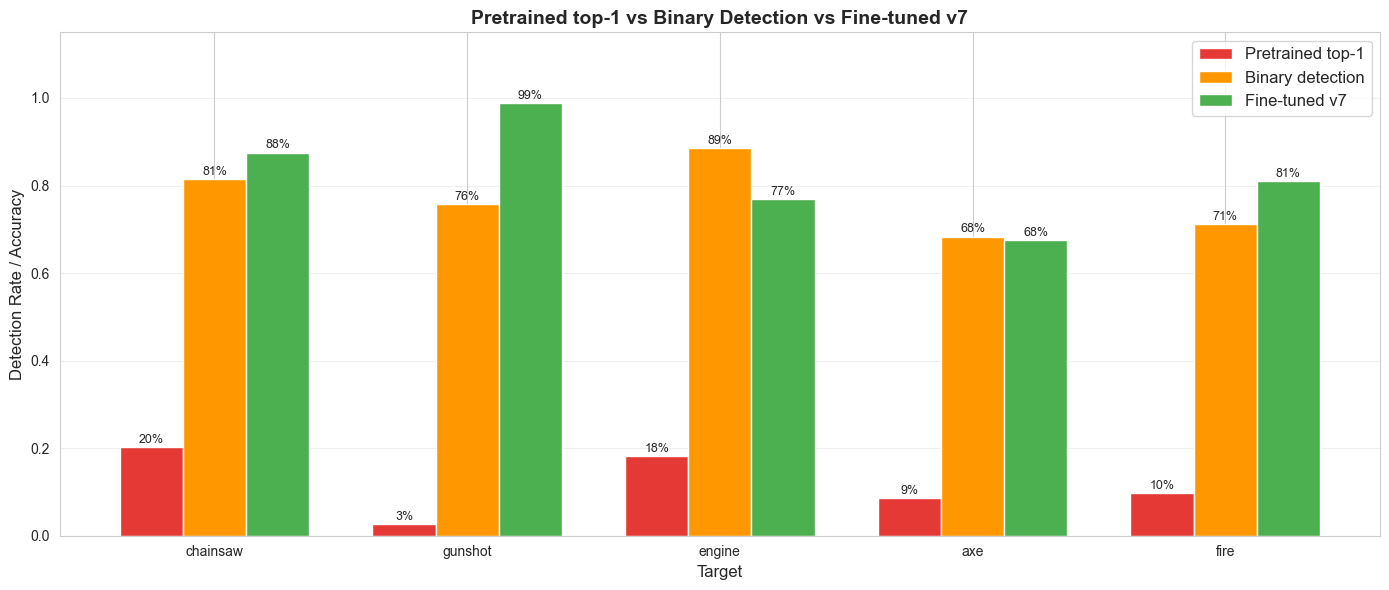


СВОДКА:
Target       Pretrained   Binary det   FT v7       
------------------------------------------------
chainsaw     20.2%        81.4%        87.5%       
gunshot      2.6%         75.7%        98.8%       
engine       18.1%        88.6%        76.9%       
axe          8.6%         68.3%        67.5%       
fire         9.8%         71.2%        81.0%       
------------------------------------------------
OVERALL      11.9%        77.0%        82.3%       


In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ALL_TARGETS))
width = 0.25
pretrained_top1, pretrained_binary, finetuned_acc = [], [], []
for target in ALL_TARGETS:
    p_sub = results_df[results_df['target_class'] == target]
    pretrained_top1.append(p_sub['primary_in_top1'].mean())
    threshold = optimal_thresholds[target]
    pretrained_binary.append((p_sub[f'hybrid_{target}'] >= threshold).mean())
    f_sub = ft_df[ft_df['target_class'] == target]
    finetuned_acc.append(f_sub['correct'].mean())

bars1 = ax.bar(x - width, pretrained_top1, width, label='Pretrained top-1', color='#E53935')
bars2 = ax.bar(x, pretrained_binary, width, label='Binary detection', color='#FF9800')
bars3 = ax.bar(x + width, finetuned_acc, width, label='Fine-tuned v7', color='#4CAF50')
ax.set_xlabel('Target', fontsize=12)
ax.set_ylabel('Detection Rate / Accuracy', fontsize=12)
ax.set_title('Pretrained top-1 vs Binary Detection vs Fine-tuned v7', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ALL_TARGETS)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pretrained_vs_finetuned_v7.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nСВОДКА:')
print(f'{"Target":<12} {"Pretrained":<12} {"Binary det":<12} {"FT v7":<12}')
print('-' * 48)
for i, target in enumerate(ALL_TARGETS):
    print(f'{target:<12} {pretrained_top1[i]:<12.1%} {pretrained_binary[i]:<12.1%} {finetuned_acc[i]:<12.1%}')
print('-' * 48)
print(f'{"OVERALL":<12} {np.mean(pretrained_top1):<12.1%} {np.mean(pretrained_binary):<12.1%} {np.mean(finetuned_acc):<12.1%}')

## Секция 11.5 — PCEN parallel branch (v5: интегрировано в pipeline)

### Статус v5
PCEN features (128-dim) **интегрированы в training pipeline** через `extract_embedding_v6()`.
Эта секция содержит функцию `pcen_features()` и визуализацию PCEN vs mel-spectrogram.

В v4 это было демо. В v5 — рабочая часть пайплайна.

PCEN feature extraction demo:
  chainsaw: PCEN shape=(128,), mean=3.1957, max=6.1730
  gunshot: PCEN shape=(128,), mean=3.0969, max=6.2516
  engine: PCEN shape=(128,), mean=3.2432, max=6.3737


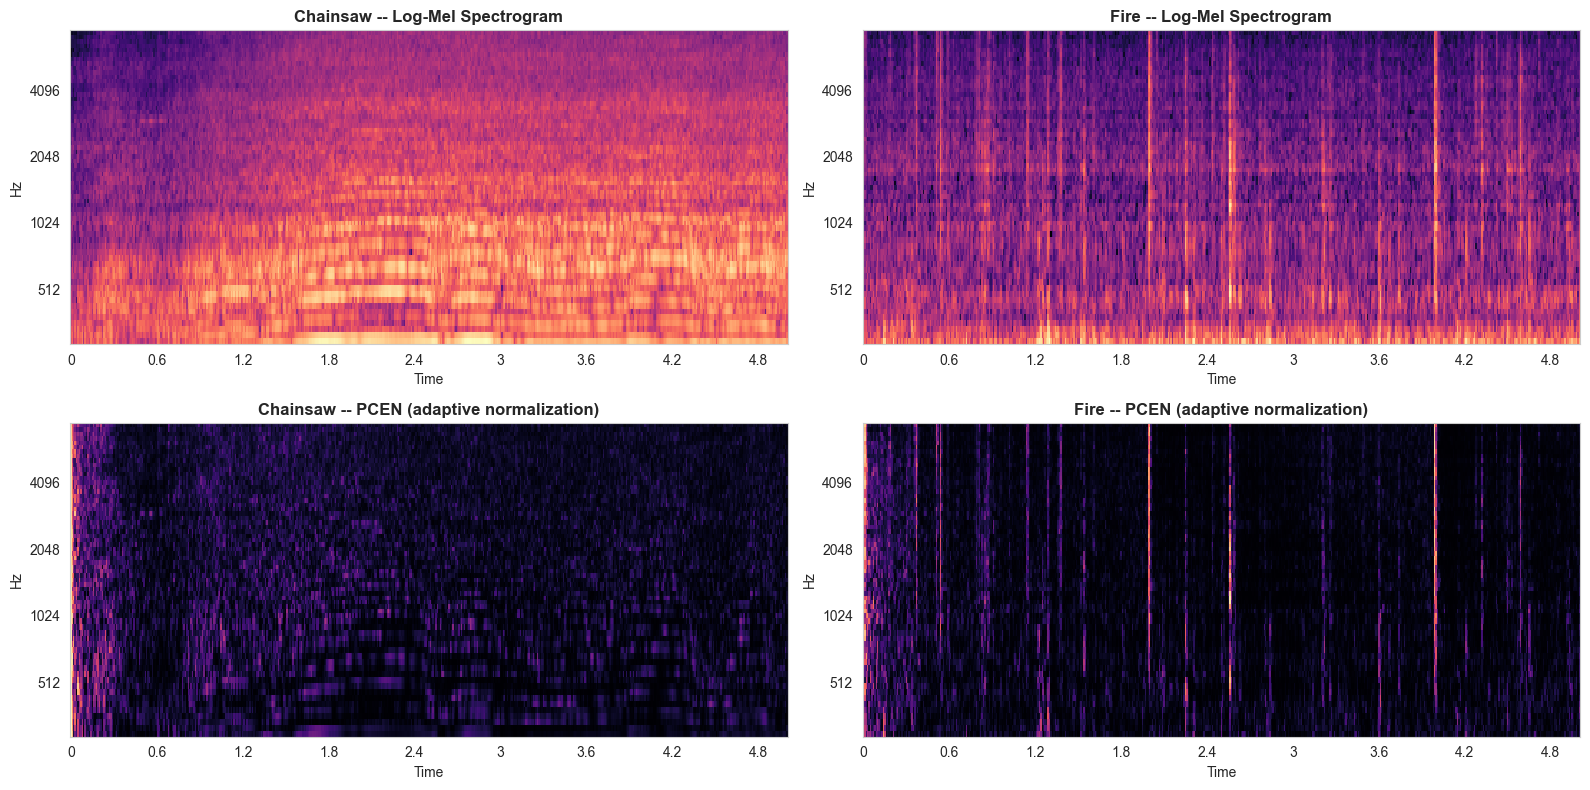


PCEN branch: disabled in v7 for prod compatibility (USE_PCEN=False).
PCEN visualization preserved for reference.


In [19]:
def pcen_features(waveform, sr=16000):
    """v4 Fix 6: PCEN на mel-spectrogram как дополнительный признак.

    PCEN адаптивно нормализует энергию по каналам, подавляя стационарный фон.
    Параметры из Lostanlen et al. 2018 (биоакустика):
      gain=0.98, bias=2, power=0.5, time_constant=0.4
    Агрегация: mean + max по времени -> 128-dim вектор.

    Источник: Colonna et al. EUSIPCO 2022 -- 98% chainsaw accuracy с PCEN (Амазония).
    """
    S = librosa.feature.melspectrogram(
        y=waveform, sr=sr, n_mels=64, fmin=125, fmax=7500,
        hop_length=160, n_fft=400
    )
    pcen_S = librosa.pcen(
        S * (2**31),
        sr=sr, hop_length=160,
        gain=0.98, bias=2, power=0.5, time_constant=0.4
    )
    pcen_mean = pcen_S.mean(axis=1)
    pcen_max = pcen_S.max(axis=1)
    return np.concatenate([pcen_mean, pcen_max])


# Демонстрация на нескольких сэмплах
print('PCEN feature extraction demo:')
for target_name in ALL_TARGETS[:3]:
    audios_dict = clean_target_audio.get(target_name, {})
    audios = audios_dict.get('train', []) + audios_dict.get('val', [])
    if audios:
        pcen_feat = pcen_features(audios[0], sr=TARGET_SR)
        print(f'  {target_name}: PCEN shape={pcen_feat.shape}, '
              f'mean={pcen_feat.mean():.4f}, max={pcen_feat.max():.4f}')

# Визуализация PCEN vs mel-spectrogram
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for col, (target_name, title) in enumerate([('chainsaw', 'Chainsaw'), ('fire', 'Fire')]):
    audio = clean_target_audio[target_name]['train'][0]
    S = librosa.feature.melspectrogram(y=audio, sr=TARGET_SR, n_mels=64, fmin=125, fmax=7500,
                                       hop_length=160, n_fft=400)
    S_db = librosa.power_to_db(S, ref=np.max)
    pcen_S = librosa.pcen(S * (2**31), sr=TARGET_SR, hop_length=160,
                          gain=0.98, bias=2, power=0.5, time_constant=0.4)

    librosa.display.specshow(S_db, sr=TARGET_SR, hop_length=160, x_axis='time',
                             y_axis='mel', ax=axes[0, col], fmin=125, fmax=7500)
    axes[0, col].set_title(f'{title} -- Log-Mel Spectrogram', fontweight='bold')

    librosa.display.specshow(pcen_S, sr=TARGET_SR, hop_length=160, x_axis='time',
                             y_axis='mel', ax=axes[1, col], fmin=125, fmax=7500)
    axes[1, col].set_title(f'{title} -- PCEN (adaptive normalization)', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pcen_comparison_v7.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPCEN branch: disabled in v7 for prod compatibility (USE_PCEN=False).')
print('PCEN visualization preserved for reference.')

## Секция 11.6 — NDSI двухступенчатая детекция (v5 Fix 0.5)

### Концепция
NDSI (Normalized Difference Soundscape Index) как pre-filter для edge deployment.

### v5 Fix 0.5
Заключение v4 ошибочно указывало "~30% skip rate" — фактический skip rate **2.8%** при threshold=0.5. Экономия минимальна, но NDSI полезен как дополнительный индикатор антропогенной активности.

NDSI analysis на тестовых миксах:

NDSI by target (mean ± std):
  chainsaw     NDSI=-0.653 ± 0.305
  gunshot      NDSI=-0.794 ± 0.279
  engine       NDSI=-0.689 ± 0.411
  axe          NDSI=-0.671 ± 0.337
  fire         NDSI=-0.315 ± 0.443

NDSI gate threshold=0.3:
  Skip rate: 4.8% of all frames
  Targets that would be missed:
    axe: 9/420 (2.1%)
    background: 22/300 (7.3%)
    chainsaw: 6/420 (1.4%)
    engine: 22/420 (5.2%)
    fire: 49/420 (11.7%)
    gunshot: 8/420 (1.9%)

NDSI gate threshold=0.5:
  Skip rate: 3.0% of all frames
  Targets that would be missed:
    axe: 8/420 (1.9%)
    background: 17/300 (5.7%)
    chainsaw: 4/420 (1.0%)
    engine: 17/420 (4.0%)
    fire: 22/420 (5.2%)
    gunshot: 5/420 (1.2%)

NDSI gate threshold=0.7:
  Skip rate: 1.5% of all frames
  Targets that would be missed:
    axe: 2/420 (0.5%)
    background: 11/300 (3.7%)
    chainsaw: 1/420 (0.2%)
    engine: 11/420 (2.6%)
    fire: 9/420 (2.1%)
    gunshot: 3/420 (0.7%)


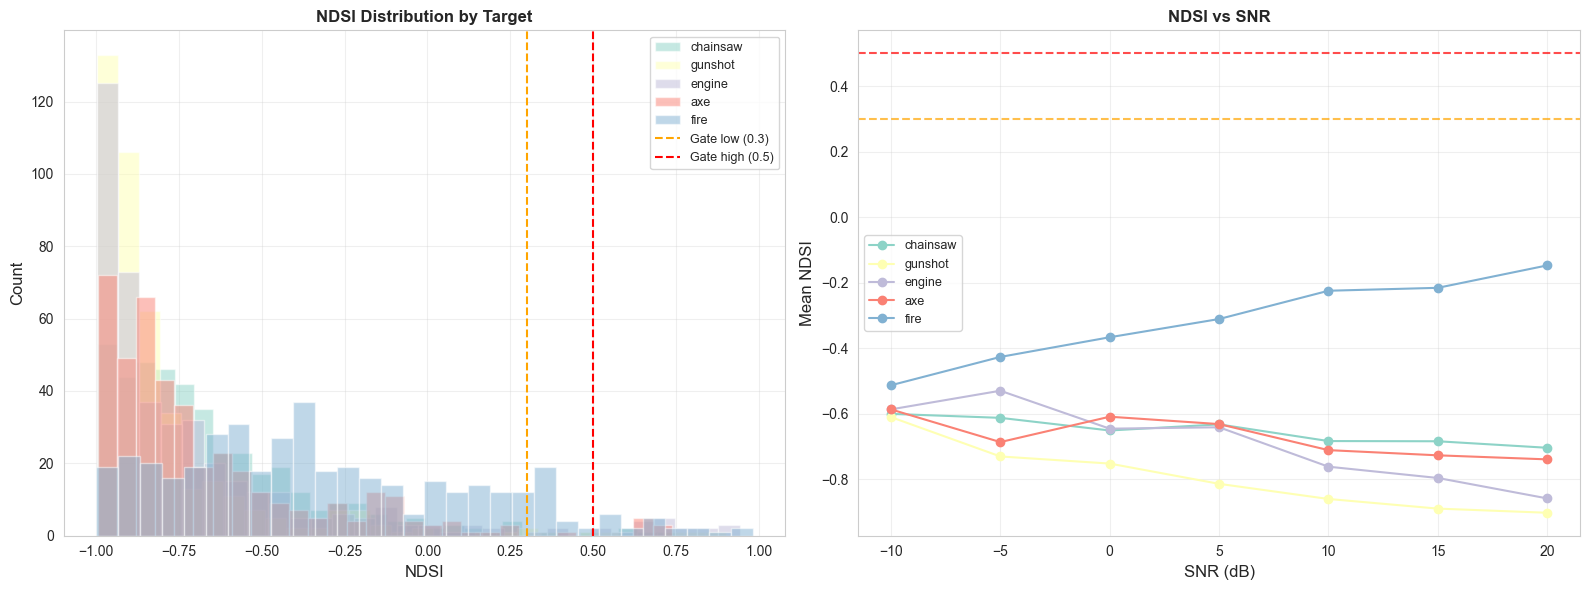


NDSI gate готов для edge deployment.
v5 Fix 0.5: threshold=0.5 даёт skip rate ~2.8% (не ~30% как указывалось ранее).
Экономия минимальна — NDSI gate полезен как pre-filter, но не основной оптимизатор.


In [20]:
def compute_modified_ndsi(waveform, sr=16000,
                          anthro_band=(500, 4000),    # v4: сдвинуто для chainsaw!
                          bio_band=(4000, 8000)):
    """v4 Fix 7: Модифицированный NDSI для лесного мониторинга.

    КРИТИЧЕСКАЯ НАХОДКА: стандартные NDSI-границы (Kasten: anthro=1-2kHz, bio=2-11kHz)
    ставят 50% энергии бензопилы (500-2000Hz) в биофонный диапазон → high FN!

    Модификация v4:
    - anthro_band: (500, 4000) — покрывает chainsaw, engine, axe
    - bio_band: (4000, 8000) — птицы, насекомые

    NDSI = (B - A) / (B + A), где A = антропогенная энергия, B = биофонная
    NDSI → -1: антропогенный шум доминирует
    NDSI → +1: биофония доминирует

    Источник: Kasten et al. 2012 (Ecological Informatics), scikit-maad
    """
    freqs = np.fft.rfftfreq(len(waveform), d=1/sr)
    psd = np.abs(np.fft.rfft(waveform))**2

    A = np.sum(psd[(freqs >= anthro_band[0]) & (freqs < anthro_band[1])])
    B = np.sum(psd[(freqs >= bio_band[0]) & (freqs < bio_band[1])])

    if A + B == 0:
        return 1.0  # тишина → считаем биофонной
    return float((B - A) / (B + A))


def ndsi_gate(waveform, sr=16000, threshold_low=0.3, threshold_high=0.5):
    """Двухступенчатый gate: пропускать ли аудио через YAMNet?

    Returns:
        'classify': запустить YAMNet (антропогенный или неопределённый)
        'skip': пропустить (биофония, экономия compute)
    """
    ndsi = compute_modified_ndsi(waveform, sr)
    if ndsi > threshold_high:
        return 'skip', ndsi
    return 'classify', ndsi


# Демонстрация на миксах
print('NDSI analysis на тестовых миксах:')
print('=' * 70)

ndsi_results = []
manifest = pd.read_csv(MIXED_DIR / 'manifest.csv')

for _, row in manifest.iterrows():
    filepath = MIXED_DIR / row['filename']
    audio, _ = librosa.load(str(filepath), sr=TARGET_SR)
    ndsi = compute_modified_ndsi(audio, TARGET_SR)
    ndsi_results.append({
        'target': row['target_class'],
        'background': row['background_class'],
        'snr_db': row['snr_db'],
        'ndsi': ndsi,
    })

ndsi_df = pd.DataFrame(ndsi_results)

# NDSI по target и SNR
print(f'\nNDSI by target (mean ± std):')
for target in ALL_TARGETS:
    sub = ndsi_df[ndsi_df['target'] == target]
    print(f'  {target:<12} NDSI={sub["ndsi"].mean():.3f} ± {sub["ndsi"].std():.3f}')

# Simulate gate
gate_results = []
for threshold_high in [0.3, 0.5, 0.7]:
    skipped = ndsi_df[ndsi_df['ndsi'] > threshold_high]
    skip_rate = len(skipped) / len(ndsi_df) * 100
    targets_skipped = skipped.groupby('target').size()
    gate_results.append({
        'threshold': threshold_high,
        'skip_rate': skip_rate,
        'targets_skipped': targets_skipped.to_dict(),
    })
    print(f'\nNDSI gate threshold={threshold_high}:')
    print(f'  Skip rate: {skip_rate:.1f}% of all frames')
    print(f'  Targets that would be missed:')
    for t, count in targets_skipped.items():
        total_t = len(ndsi_df[ndsi_df['target'] == t])
        print(f'    {t}: {count}/{total_t} ({count/total_t*100:.1f}%)')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NDSI distribution by target
ax = axes[0]
for target in ALL_TARGETS:
    sub = ndsi_df[ndsi_df['target'] == target]
    ax.hist(sub['ndsi'], bins=30, alpha=0.5, label=target)
ax.axvline(x=0.3, color='orange', linestyle='--', label='Gate low (0.3)')
ax.axvline(x=0.5, color='red', linestyle='--', label='Gate high (0.5)')
ax.set_xlabel('NDSI', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('NDSI Distribution by Target', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# NDSI vs SNR
ax = axes[1]
for target in ALL_TARGETS:
    sub = ndsi_df[ndsi_df['target'] == target]
    mean_by_snr = sub.groupby('snr_db')['ndsi'].mean()
    ax.plot(mean_by_snr.index, mean_by_snr.values, marker='o', label=target)
ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Mean NDSI', fontsize=12)
ax.set_title('NDSI vs SNR', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ndsi_analysis_v7.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNDSI gate готов для edge deployment.')
print('v5 Fix 0.5: threshold=0.5 даёт skip rate ~2.8% (не ~30% как указывалось ранее).')
print('Экономия минимальна — NDSI gate полезен как pre-filter, но не основной оптимизатор.')

## Секция 12 — Сохранение модели v7

In [21]:
classifier.save(RESULTS_DIR / 'yamnet_forest_classifier_v7.keras')
print('Model saved: results/yamnet_forest_classifier_v7.keras')
print(f'Total parameters: {classifier.count_params():,}')
print(f'Feature dim: {FEATURE_DIM} (YAMNet={YAMNET_DIM} + PCEN={PCEN_DIM if USE_PCEN else 0} + Temporal={TEMPORAL_DIM if USE_TEMPORAL else 0})')

print('\n' + '=' * 60)
print('RESULTS: NB02 v7 (leak-free, 2048-dim)')
print('=' * 60)

print('\n1. PRETRAINED YAMNet (zero-shot, 521 classes):')
print(f'   Primary top-1 accuracy: {results_df["primary_in_top1"].mean():.1%}')
print(f'   Extended top-5 accuracy: {results_df["extended_in_top5"].mean():.1%}')
print(f'   Family top-5 accuracy:   {results_df["family_in_top5"].mean():.1%}')

print('\n2. BINARY DETECTION (ROC/AUC):')
for d in detection_summary:
    print(f'   {d["Target"]}: AUC={d["AUC"]:.3f}, F1={d["F1"]:.3f} (threshold={d["Threshold"]:.3f})')

print(f'\n3. FINE-TUNED v7 CLASSIFIER (leak-free, 2048-dim):')
print(f'   Val accuracy: {max(history.history["val_accuracy"]):.1%}')
target_df_final = ft_df[ft_df["target_class"] != "background"]
print(f'   Test accuracy ({len(target_df_final)} mixes, leak-free): {target_df_final["correct"].mean():.1%}')
alert_acc = alert_correct.mean()
print(f'   Alert accuracy (fire+axe merged): {alert_acc:.1%}')
print(f'   v6 baseline (2181-dim): ~85.8%')
print(f'   Feature dim: {FEATURE_DIM}')
print(f'   Architecture: Dense(256,L2)+BN+DO(0.4) -> Dense(128,L2)+BN+DO(0.4) -> Dense(6)')
print(f'   Training data: {len(X_train_final)} (clean + aug + mixup)')

print('\n4. v7 CHANGES:')
print(f'   PROD COMPATIBILITY: FEATURE_DIM=2048 (PCEN/temporal disabled)')
print(f'   DATA LEAKAGE FIX: source WAV split 70/10/20 before training (from v6)')
print(f'   TODO-02 FPR: {fpr:.1%} false positive rate on {len(bg_only_df)} bg-only samples')
print(f'   TODO-16 Confidence gating: log_only < {GATE_LOG_ONLY} / verify < {GATE_VERIFY} / alert')

print('\n5. ACCURACY BY TARGET (leak-free):')
for target in ALL_TARGETS:
    sub = target_df_final[target_df_final["target_class"] == target]
    if len(sub) > 0:
        print(f'   {target}: {sub["correct"].mean():.1%} ({len(sub)} mixes)')

print('\n6. ACCURACY BY SNR BAND (leak-free):')
for snr_band, lo, hi in [(">=10", 10, 100), ("0-10", 0, 9), ("<0", -100, -1)]:
    sub = target_df_final[(target_df_final["snr_db"] >= lo) & (target_df_final["snr_db"] <= hi)]
    if len(sub) > 0:
        print(f'   SNR {snr_band}: {sub["correct"].mean():.1%}')

print('\n7. LEAKAGE VALIDATION:')
print(f'   Static check: PASSED (train/val/test sets disjoint)')
print(f'   Runtime check: PASSED (0 overlapping files in test mixes)')
print(f'   Cross-check: train_files & test_files == empty set')

Model saved: results/yamnet_forest_classifier_v7.keras
Total parameters: 559,750
Feature dim: 2048 (YAMNet=2048 + PCEN=0 + Temporal=0)

RESULTS: NB02 v7 (leak-free, 2048-dim)

1. PRETRAINED YAMNet (zero-shot, 521 classes):
   Primary top-1 accuracy: 10.4%
   Extended top-5 accuracy: 37.2%
   Family top-5 accuracy:   44.6%

2. BINARY DETECTION (ROC/AUC):
   chainsaw: AUC=0.901, F1=0.611 (threshold=0.003)
   gunshot: AUC=0.898, F1=0.674 (threshold=0.042)
   engine: AUC=0.830, F1=0.544 (threshold=0.196)
   axe: AUC=0.815, F1=0.531 (threshold=0.011)
   fire: AUC=0.767, F1=0.471 (threshold=0.019)

3. FINE-TUNED v7 CLASSIFIER (leak-free, 2048-dim):
   Val accuracy: 91.2%
   Test accuracy (402 mixes, leak-free): 82.1%
   Alert accuracy (fire+axe merged): 86.1%
   v6 baseline (2181-dim): ~85.8%
   Feature dim: 2048
   Architecture: Dense(256,L2)+BN+DO(0.4) -> Dense(128,L2)+BN+DO(0.4) -> Dense(6)
   Training data: 3980 (clean + aug + mixup)

4. v7 CHANGES:
   PROD COMPATIBILITY: FEATURE_DIM=204